# Project 4: Probabilistic Modeling

## Objectives

This project focuses on probabilistic models and how to fit them.

By the end of this project, you will have implemented the underlying models and fitting procedures:
- Naive Bayes for text classification
- Mixture of Bernoullis (fit via Expectation-Maximization) for generative image modeling
- Posterior inference and online EM
- Gaussian Bayes Classifier, Fisher's LDA, and Logistic Regression on various binary classification tasks.


## Deliverable
* **Project report/writeup**: A `project4_report_lastname.pdf` file containing your **full solution**, including corresponding plots and results. Follow the `Project 4 - Report (Individual Submission)` link on Gradescope to upload this file. **The report must be self-contained**. 
  - For coding questions, you must include the relevant code snippets and execution results (outputs/plots, if applicable) directly in this PDF. Justifications such as "refer to the source code" are not acceptable. 
  - The report should also include a brief justification of your solution at a high level (e.g., using relevant explanations, equations, or diagrams) and a description of your code structure (e.g., a few sentences per function).



* **Source code**: A `project4_src_lastname1[_lastname2].ipynb` (or `.zip`) file with a working copy of your solutions compiled in a Jupyter notebook. Follow the `Project 4 - Source Code (Group Submission)` link to upload this file.


## Logistics

* You can work in groups of 1-2 students for each course project, and it's your responsibility to find a group (e.g. use Ed Discussion). 
* Every member of a group must complete and submit the project report/writeup individually. While the source code can be the same for all group members, the project report needs to be written independently by each person and, thus, should differ among team member and students more generally.
* One group member need to submit the source code. If you submit as a group, make sure to include your teammate in the group submission. Instructions for team submission can be found [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
* Grades will be provided based on the individual project report. The source code submission will not be graded, but the teaching staff may check the source files if they see the need for reproducing your results when going through your project report. 
* Failure to submit the source code will lead to a deduction of points from your total.

* ⚠️ <span style="color:red"> [For Project 4] </span> **Question Matching**: When uploading your PDF report to Gradescope, you must manually map your response pages to the corresponding questions. <span style="color:red">  Failure to properly match questions will result in point deductions.</span> 


In [80]:
%config InlineBackend.figure_format = 'retina'

## Task 4A: Naïve Bayes (30pt)

In this assignment, you will be implementing the Naïve Bayes classifier to perform text classification. The Naïve Bayes classifier is a probabilistic machine learning model that is based on Bayes' theorem. It is particularly useful for classification tasks involving high-dimensional data such as text classification.

### Background

#### Bayes' Theorem

Bayes' theorem describes the probability of an event, based on prior knowledge of conditions that might be related to the event. For a class variable $Y$ and a dependent feature vector $X_1$ through $X_n$, Bayes' theorem is stated as:

$$P(Y|X) = \frac{P(X|Y)P(Y)}{P(X)}$$

In the context of text classification, $Y$ represents a particular class (e.g., spam or not spam), and $X$ represents a text document. The theorem is applied to calculate the probability of a document belonging to a class, given the observed words in the document.

#### Naïve Bayes

The Naïve Bayes classifier simplifies the calculation by assuming that the features (words in the case of text classification) are conditionally independent given the class. This assumption allows us to factorize the joint probability $P(X|Y)$ into a product of *individual* probabilities:

$$P(X|Y) = \prod_{i=1}^{n} P(X_i|Y)$$

where $P(X_i|Y)$ is the probability of word $i$ occurring in a document of class $Y$.

This assumption dramatically simplifies the fitting procedure. Naturally, this model is "naive" because the features are typically not so simple as to be independent of each other, even conditioned on the class label.

#### Using the class-conditional density for classification

Suppose we have some class $c$ and a feature vector $x \in \mathbb{R}^d$. We directly model the density of data as
$$ P_{\theta}(x | y=c) = \prod_{i=1}^d P_{\theta_{ic}}(x_i|y=c) $$
where the $\theta_{ic}$ parameters describe the density of the $i$-th feature in class $c$. For example, if the features are binary, we might use Bernoulli distributions for each feature in each class.

In our case, we will be using the Gaussian distribution to model the data density $P(X|Y)$.
As such, our probabilities $P_{\theta_{ic}}(x_i | y=c)$ will come from the Gaussian density.

Once the parameters have been estimated on some training set, we can classify new data by computing the posterior over the class labels (our model's output of probabilities for each class given some input test data point $x$) using Bayes' theorem:

$$ P_{\theta}(y=c | x) = \frac{ P_{\theta}(y=c) \prod_{i=1}^d P_{\theta}(x_i | y=c) }{ \sum_{c'} P_{\theta}(y=c') \prod_{i=1}^d P_{\theta}(x_i | y=c') } $$

For further reading on Naive Bayes, see Section 9.3 in Murphy's Probabilistic Machine Learning (2022).

### Dataset

In [81]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def create_dataset():
    """
    Creates a synthetic dataset for binary classification with two features.
    
    Returns:
        tuple: (X, y)
            - X: feature matrix, ndarray of shape (1250, 2)
            - y: binary class labels (0 or 1), ndarray of shape (1250,)
    """
    X, y = make_classification(n_samples=1250, n_features=2, n_redundant=0, 
                             n_informative=2, random_state=1, 
                             n_clusters_per_class=1)
    
    # Add random noise to make the dataset linearly inseparable
    rng = np.random.RandomState(2)
    X += 3 * rng.uniform(size=X.shape)
    
    # Standardize features by removing the mean and scaling to unit variance
    X = StandardScaler().fit_transform(X)
    
    return X, y

X, y = create_dataset()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Starter Code

In [82]:
def gaussian_pdf(x: np.ndarray, mean: float, var: float) -> np.ndarray:
    """
    Calculate the Gaussian (Normal) probability density
    f(x) = (1 / sqrt(2π * σ²)) * exp(-(x - μ)² / (2σ²))
    
    Args:
        x : Input value(s) where we want to compute the probability density,
            np.ndarray of shape (n_samples,) or float
        mean : μ, float
        var : σ², float
    
    Returns:
        The probability density at each point x: np.ndarray of shape (n_samples,) or float
    """
    eps = 1e-4  # small constant to prevent division by zero
    coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
    exponent = np.exp(-(np.power(x - mean, 2) / (2 * var + eps)))
    return coeff * exponent

def evaluate_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """ Calculates the classification accuracy. """
    return np.sum(y_true == y_pred) / len(y_true)

### Task 4A.1 (5 pts): Calculate Prior Probabilities 

Note that in the $P_{\theta}(y=c|x)$ expression we have from earlier, we have the prior class probabilities $P_{\theta}(y=c)$. You can think of this as the empirical probability of seeing class $c$ in the training data. We can calculate these probabilities by counting the occurrences of each class in the training data and dividing by the total number of samples.

Implement the function `calculate_class_priors(y_train)` to calculate and return the prior probabilities \(P(Y)\) of each class in the training dataset.

**Report**: just include code snippets of your implementation and the outputs. No need to justify/describe.

In [83]:
def calculate_class_priors(y_train: np.ndarray) -> dict:
    """
    Calculates the prior probabilities P(Y) for each class in the training set.
    Prior probability P(Y=k) = (number of samples in class k) / (total samples)

    Args:
        y_train : np.ndarray of shape (n_samples,)

    Returns:
        Dictionary mapping class labels to their prior probabilities
            - Keys: class labels (int)
            - Values: prior probabilities (float in range [0, 1])
    """
    priors = {}
    total_samples = len(y_train)

    for cls in np.unique(y_train): # np.unique(y_train) gets unique class labels
        #! YOUR CODE STARTS HERE
        priors[cls] = np.sum(y_train == cls) / total_samples
        #! YOUR CODE ENDS HERE
        
    return priors

# Test the function with an example
y_train_example = np.array([0, 1, 0, 0, 1, 0])
priors = calculate_class_priors(y_train_example)
print("Training labels:", y_train_example)
print("Prior probabilities:", priors)
print("Sum of probabilities:", sum(priors.values()))

Training labels: [0 1 0 0 1 0]
Prior probabilities: {0: 0.6666666666666666, 1: 0.3333333333333333}
Sum of probabilities: 1.0


### Task 4A.2 (5 pts): Calculate class-conditional density parameters

Implement the function `calculate_gaussian_density_params(features, labels)` to calculate the parameters of the class-conditional data density \(P(X|Y)\) of observing each feature given each class. Since we're using Gaussians to model the distribution of each feature, you simply need to compute the mean and variance of each feature, conditional on a class.

**Report**: just include code snippets of your implementation and the outputs. No need to justify/describe.

In [84]:
def calculate_gaussian_density_params(features: np.ndarray, labels: np.ndarray) -> dict:
    """
    Calculates the parameters (mean, var) for Gaussian likelihood P(X|Y)
    for each feature conditioned on each class.C
    Uses ddof=1 for variance calculation (unbiased estimator).

    Args: 
        features : np.ndarray of shape (n_samples, n_features)
        labels : np.ndarray of shape (n_samples,)

    Returns:
        Dictionary mapping class labels to list of (mean, var) tuples
        for each feature.
        { class_0: [(mean_feat1, var_feat1), (mean_feat2, var_feat2), ...],
          class_1: [(mean_feat1, var_feat1), (mean_feat2, var_feat2), ...]  }

    Example:
    >>> features = [[1.0, 2.3],
                    [0.5, 1.8],
                    [2.3, 3.2]]
    >>> labels = np.array([0, 1, 0])
    >>> calculate_gaussian_density_params(features, labels)
    {0: [(1.65, 0.845), (2.75, 0.405)], 1: [(0.5, 0.0), (1.8, 0.0)]}
    """
    likelihood = {}
    
    for cls in np.unique(labels):
        class_mask = (labels == cls)
        class_features = features[class_mask] # Shape: (n_samples_in_class, n_features)
        class_stats = []

        # Calculate statistics for each feature in current class
        # zip(*class_features) transposes the feature matrix for per-feature calculation
        for feature in zip(*class_features):
            # feature is now a tuple of all values for one feature in current class

            #! YOUR CODE STARTS HERE
            mean_feat = np.mean(feature)
            var_feat = np.var(feature, ddof=1)
            mean_var = (mean_feat, var_feat)
            class_stats.append(mean_var)
            #! YOUR CODE ENDS HERE
        
        likelihood[cls] = class_stats
    return likelihood

# Test the function with an example
X = np.array([[2.0, 3.3],
              [0.5, 1.8],
              [2.3, 3.2],
              [3.0, 2.0]])  # 4 samples, 2 features
y = np.array([0, 0, 1, 0])  # Binary labels

params = calculate_gaussian_density_params(X, y)
for cls in params:
    print(f"\nClass {cls}:")
    for i, (mean, var) in enumerate(params[cls]):
        print(f"Feature {i+1}:  Mean (μ) = {mean:.3f}")
        print(f"            Var (σ²) = {var:.3f}")


Class 0:
Feature 1:  Mean (μ) = 1.833
            Var (σ²) = 1.583
Feature 2:  Mean (μ) = 2.367
            Var (σ²) = 0.663

Class 1:
Feature 1:  Mean (μ) = 2.300
            Var (σ²) = nan
Feature 2:  Mean (μ) = 3.200
            Var (σ²) = nan


/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Task 4A.3 (20 pts): Implement and run the classifier

Implement the `naive_bayes_classifier(X_train, y_train, X_test)` function. This function should use the priors and likelihoods calculated in the previous tasks to classify each sample in the test set. Apply Bayes' theorem to compute the posterior probability for each class given the sample and predict the class with the highest posterior probability.

Then, verify the performance of the classifier you just implemented. You should see a test accuracy > 75%.

**Report**: include code snippets of your implementation and the output. Justify your solution and describe your code. 

In [85]:
def naive_bayes_classifier(X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> np.ndarray:
    """
    Implements Naive Bayes classification using Gaussian density estimation.
    X_train and X_test should be standardized/scaled before being passed to this function.
    Class labels should be integers starting from 0. 

    Args: 
        X_train : np.ndarray of shape (n_train_samples, n_features)
        y_train : np.ndarray of shape (n_train_samples,)
        X_test : np.ndarray of shape (n_test_samples, n_features) 

    Returns:
        predictions : np.ndarray of shape (n_test_samples,)
    """
    predictions = []
    priors = calculate_class_priors(y_train)  
    density_params = calculate_gaussian_density_params(X_train, y_train)

    # Make prediction for each test sample
    
    #! YOUR CODE STARTS HERE
    X_train = (X_train - np.mean(X_train)) / np.std(X_train)
    X_test = (X_test - np.mean(X_train)) / np.std(X_train)
    for x in X_test:
        most_likely_class = None
        for cls in priors:
            prior = priors[cls]
            log_sum_1 = np.log(prior)
            log_sum_2 = 0.0
            for i in range(len(x)):
                mean, var = density_params[cls][i]
                gaussian_likelihood = gaussian_pdf(x[i], mean, var)
                log_sum_2 += np.log(gaussian_likelihood)
            log_posterior = log_sum_1 + log_sum_2
            if most_likely_class is None or log_posterior > most_likely_class[1]:
                most_likely_class = (cls, log_posterior)
        predictions.append(most_likely_class[0])
    #! YOUR CODE ENDS HERE

    return np.array(predictions, dtype=np.int64)

predictions = naive_bayes_classifier(X_train, y_train, X_test)
accuracy = evaluate_accuracy(predictions, y_test)
print(f"The test accuracy is {accuracy * 100}%.")

The test accuracy is 78.0%.


***Please discuss*** at least two potential bottlenecks of performance on the current implementations.

`YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

`YOUR ANSWER ENDS HERE`

## Task 4B: Image Completion with Mixture of Bernoullis and EM (70pt)

### Background

#### Mixture of Bernoullis
Each image we'll deal with is 28-by-28, and each pixel takes values in $\{0, 1\}$. For simplicity, we ignore the spatial structure of the images, and flatten the image into a 784-dimensional binary vectors.

Each mixture of Bernoullis component consists of a collection of independent Bernoulli random variables. By denoting the image as $\mathbf{x} \in \{ 0, 1\}^{784}$, and the latent variable $z$. Then the conditional probability of an image $\mathbf{x} = \mathbf{x}^{(i)}$ given the label ${z}=k$ is
\begin{align}
    p(\mathbf{x}^{(i)}|{z}=k)&= \prod_{j=1}^{784} p(\mathbf{x}_{j}^{(i)}|z=k) \\
    & =  \prod_{j=1}^{784} \mathbf{\theta}_{k, j}^{\mathbf{x}_{j}^{(i)}} (1-\mathbf{\theta}_{k, j})^{1-\mathbf{x}_{j}^{(i)}}
\end{align}


You should try to understand where this formula comes from. You'll find it useful when you do the derivations. This can be written out as the following generative process:

1. Sample z from a multinomial distribution with parameter vector $\mathbf{\pi}$, where $\mathbf{\pi}$ is a $K$-dimensional vector in our case.

2. For j = 1, ..., 784: Sample $\mathbf{x}_j$ from a Bernoulli distribution with parameter $\mathbf{\theta}_{k,j}$, where $k$ is the value of $z$ from the first step.

More formally, this can be written mathematically as:
$$z \sim \text{Multinomial}(\mathbf{\pi})$$
$$x_j|z=k \sim \text{Bernoulli}(\theta_{k,j})$$



#### Summary of notations

The inputs (i.e., the training data) are represented by $\mathbf{X}$, which is a $N$-by-$D$ binary matrix, where $N$ is the number of samples, and $D$ is the number of dimensions. In the E-step,we compute $\mathbf{R}$, the matrix of membership weights, which is a $N$-by-$K$ matrix with $K$ being the number of components. Each row of $\mathbf{R}$ gives the membership weights for one training example.

The **trainable parameters** of the model, written out as vectors and matrices, are:

$$\mathbf{\pi} = \begin{bmatrix}\pi_1 \\ \pi_2 \\\cdots \\ \pi_K\end{bmatrix}$$
$$\mathbf{\Theta} = \begin{bmatrix} \theta_{1,1} & \theta_{1,2} & \ldots & \theta_{1, N} \\ \theta_{2,1} & \theta_{2,2} & \ldots & \theta_{2, N} \\ \cdots & & \ddots & \cdots \\ \theta_{K,1} & \theta_{K,2} & \ldots & \theta_{K, N}\end{bmatrix}$$

Since we are using the MNIST dataset, we have $N=60000$, and $D=784$.

### Starter code

This code has been provided for you; there is no need to modify it.

In [86]:
import numpy as np
import pylab
import time

# import checking
import util  # see util.py under this project folder

try:
    from scipy.special import gammaln
except:
    pass

IMAGE_DIM = 28

TRAIN_IMAGES_FILE = 'train-images-idx3-ubyte'
TRAIN_LABELS_FILE = 'train-labels-idx1-ubyte'
TEST_IMAGES_FILE = 't10k-images-idx3-ubyte'
TEST_LABELS_FILE = 't10k-labels-idx1-ubyte'


def beta_log_pdf(theta, a, b):
    """Log PDF of the beta distribution. We don't need this function, but we
    include it in case you're interested. You need SciPy in order to use it."""
    norm_const = gammaln(a + b) - gammaln(a) - gammaln(b)
    return norm_const + (a - 1.) * np.log(theta) + (b - 1.) * np.log(1. - theta)


def beta_log_pdf_unnorm(theta, a, b):
    """Unnormalized log PDF of the beta distribution."""
    return (a - 1.) * np.log(theta) + (b - 1.) * np.log(1. - theta)

    
def dirichlet_log_pdf(pi, a):
    """Log PDF of the Dirichlet distribution. We don't need this function, but we
    include it in case you're interested. You need SciPy in order to use it."""
    norm_const = gammaln(a.sum()) - gammaln(a).sum()
    return norm_const + np.sum((a - 1.) * np.log(pi))


def dirichlet_log_pdf_unnorm(pi, a):
    """Unnormalized log PDF of the Dirichlet distribution."""
    return np.sum((a - 1.) * np.log(pi))


class Params(object):
    """
    A class which represents the trainable parameters of the mixture model.
    
    - pi: the mixing proportions, represented as a K-dimensional array. It must be a
          probability distribution, i.e. the entries must be nonnegative and sum to 1.
    
    - theta: The Bernoulli parameters for each pixel in each mixture component. 
             This is a K x D matrix, where rows correspond to mixture components 
             and columns correspond to pixels. 
    """

    def __init__(self, pi, theta):
        self.pi = pi
        self.theta = theta

    @classmethod
    def random_initialization(cls, num_components, num_pixels):
        init_pi = np.ones(num_components) / num_components
        init_theta = np.random.uniform(0.49, 0.51, size=(num_components, num_pixels))
        return Params(init_pi, init_theta)

        
class Prior(object):
    """
    A class representing the priors over parameters in the mixture model.
    
    - a_mix: A scalar valued parameter for the Dirichlet prior over mixing proportions.
    
    - a_pixels and b_pixels: 
             The scalar-valued parameters for the beta prior over the entries of theta. 
             I.e., the entries of theta are assumed to be drawn i.i.d. from the distribution
             Beta(a_pixels, b_pixels). 
    """

    def __init__(self, a_mix, a_pixels, b_pixels):
        self.a_mix = a_mix
        self.a_pixels = a_pixels
        self.b_pixels = b_pixels

    @classmethod
    def default_prior(cls):
        """Return a Prior instance which has reasonable values."""
        return cls(2., 2., 2.)

    @classmethod
    def uniform_prior(cls):
        """Return a set of prior parameters which corresponds to a uniform distribution. Then
        MAP estimation is equivalent to maximum likelihood."""
        return cls(1., 1., 1.)


def multinomial_entropy(p):
    """Compute the entropy of a Bernoulli random variable, in nats rather than bits."""
    p = np.clip(p, 1e-20, np.inf)      # avoid taking the log of 0
    return -np.sum(p * np.log(p))


def variational_objective(model, X, R, pi, theta):
    """Compute the variational lower bound on the log-likelihood that each step of E-M
    is maximizing. This is described in the paper

        Neal and Hinton, 1998. A view of the E-M algorithm that justifies incremental, sparse, and other variants.

    We can test the update rules by verifying that each step maximizes this bound.
    """

    model = Model(model.prior, Params(pi, theta))
    expected_log_prob = model.expected_joint_log_probability(X, R)
    entropy_term = np.sum(multinomial_entropy(R))
    return expected_log_prob + entropy_term

def perturb_pi(pi, eps=1e-6):
    pi = np.random.normal(pi, eps)
    pi = np.clip(pi, 1e-10, np.inf)
    pi /= pi.sum()
    return pi

def perturb_theta(theta, eps=1e-6):
    theta = np.random.normal(theta, eps)
    theta = np.clip(theta, 1e-10, 1. - 1e-10)
    return theta

def perturb_R(R, eps=1e-6):
    R = np.random.normal(R, eps)
    R = np.clip(R, 1e-10, np.inf)
    R /= R.sum(1).reshape((-1, 1))
    return R

def train_from_labels(prior=None, show=True):
    """Fit the mixture model using the labeled MNIST data. There are 10 mixture components,
    one corresponding to each of the digit classes."""

    X = util.read_mnist_images(TRAIN_IMAGES_FILE)
    y = util.read_mnist_labels(TRAIN_LABELS_FILE)
    X_test = util.read_mnist_images(TEST_IMAGES_FILE)
    num_data, num_pixels = X.shape

    if prior is None:
        prior = Prior.default_prior()
    model = Model.random_initialization(prior, 10, IMAGE_DIM**2)

    R = np.zeros((num_data, 10))
    R[np.arange(num_data), y] = 1.
    model.params.pi = model.update_pi(R)
    model.params.theta = model.update_theta(X, R)

    # mask which includes top half of pixels
    M = np.zeros(X.shape, dtype=int)
    M[:, :M.shape[1]//2] = 1

    if show:
        model.visualize_components()
        try:
            model.visualize_predictions(X[:64, :], M[:64, :])
        except:
            print('Posterior predictive distribution not implemented yet.')

        print('Training log-likelihood:', model.log_likelihood(X) / num_data)
        print('Test log-likelihood:', model.log_likelihood(X_test) / X_test.shape[0])

    return model

### Task 4B.1: Parameter Learning via EM (35pt)

In the first step, we’ll learn the parameters of the model given the responsibilities, using the Maximum A Posteriori (MAP) criterion. This corresponds to the M-step of the E-M (Expectation-Maximization) algorithm.

In lecture, we discussed the E-M algorithm in the context of maximum likelihood (ML) learning. This is discussed in detail in slides of Lecture 18 Gaussian Mixture Model, and **you should read those slides carefully before starting this part**.

The MAP case is only slightly different from ML: the only difference is that we add a prior probability term to the objective function in the M-step.
In particular, recall that in the context of ML, the M-step maximizes the objective function:

$$\sum_{i=1}^N \sum_{k=1}^K r^{(i)}_{k} \left[\log p(z^{(i)}=k) + \log p(x^{(i)}|z^{(i)}=k)\right]$$

where the $r^{(i)}_k$ are the membership weights computed during the E-step. In the MAP formulation, we need to incorporate
information about our prior distribution, i.e. we add the (log) prior probability of the parameters:

$$\sum_{i=1}^N \sum_{k=1}^K r^{(i)}_{k} \left[\log p(z^{(i)}=k) + \log p(x^{(i)}|z^{(i)}=k)\right] + \log p(\mathbf{\pi}) + \log p(\mathbf{\Theta})$$

Our prior for $\mathbf{\Theta}$ is as follows: every entry is drawn independently from a [beta distribution](https://en.wikipedia.org/wiki/Beta_distribution) with parameters a and b. The beta distribution is

$$p(\theta_{k,j})\propto \theta_{k,j}^{a-1}(1-\theta_{k,j})^{b-1}$$

Recall that $\propto$ means “proportional to” i.e., the distribution has a normalizing constant to ensure it integrates to 1 which we’re ignoring because we don’t need it for the M-step.

For the prior over mixing proportions $\mathbf{\pi}$, we’ll use the [Dirichlet distribution](http://en.wikipedia.org/wiki/Dirichlet_distribution), which is the conjugate prior for the multinomial distribution. It is a distribution over the probability simplex, *i.e.*, the set of vectors which define a valid probability distribution. The distribution takes the form:

$$p(\mathbf{\pi})\propto \pi_1^{a_1-1}\pi_2^{a_2-1}\ldots\pi_{K}^{a_K-1}$$

For simplicity, we use a symmetric Dirichlet prior where all the $a_k$ parameters are assumed to be **equal**. Like the beta distribution, the Dirichlet distribution has a normalizing constant which we don’t need when updating the parameters. The beta distribution is actually the special case of the Dirichlet distribution for $K = 2$.

Further reading on the EM algorithm can be found in Section 8.7 of Murphy's Probabilistic Machine Learning (2022).

#### Question: Derive the M-step update rules
Derive the M-step update rules for $\mathbf{\Theta}$ and $\mathbf{\pi}$ by setting the partial derivatives of the following equation to be zero:

$$\sum_{i=1}^N \sum_{k=1}^K r^{(i)}_{k} \left[\log p(z^{(i)}=k) + \log p(x^{(i)}|z^{(i)}=k)\right] + \log p(\mathbf{\pi}) + \log p(\mathbf{\Theta})$$

**Implementation**: Take these formulas and use them to implement the functions `Model.update_pi` and `Model.update_theta` below. Each one should be implemented in terms of NumPy matrix and vector operations. Each one requires only a few lines of code, and should not involve any for loops.

**Checking**: Once you have finished the implementation, please run `check_m_step()` for a sanity check. If you pass this sanity check, your implementation is probably correct. (You **DON'T** need to understand how the code works.)

In [87]:
class Model(object):
    """A class implementing the mixture of Bernoullis model. The fields are:
        - prior: an Prior instance
        - params: a Params instance"""

    def __init__(self, prior, params):
        self.prior = prior
        self.params = params

    @classmethod
    def random_initialization(cls, prior, num_components, num_pixels):
        params = Params.random_initialization(num_components, num_pixels)
        return cls(prior, params)

    def expected_joint_log_probability(self, X, R):
        """Compute the expected joint log probability, where the expectation is with respect to
        the responsibilities R. This is the objective function being maximized in the M-step.
        It's useful for verifying the optimality conditions in the M-step."""

        total = 0.

        # Prior over mixing proportions
        total += dirichlet_log_pdf_unnorm(self.params.pi, self.prior.a_mix)

        # Prior over pixel probabilities
        total += np.sum(beta_log_pdf_unnorm(self.params.theta, self.prior.a_pixels, self.prior.b_pixels))

        # Probability of assignments
        total += np.sum(R * np.log(self.params.pi))

        # Matrix of log probabilities of observations conditioned on z
        # The (i, k) entry is p(x^(i) | z^(i) = k)
        log_p_x_given_z = np.dot(X, np.log(self.params.theta).T) + \
                          np.dot(1. - X, np.log(1. - self.params.theta).T)

        # Observation probabilities
        total += np.sum(R * log_p_x_given_z)

        return total

    def log_likelihood(self, X):
        """Compute the log-likelihood of the observed data, i.e. the log probability with the
        latent variables marginalized out."""

        # Matrix of log probabilities of observations conditioned on z
        # The (i, k) entry is p(x^(i) | z^(i) = k)
        log_p_x_given_z = np.dot(X, np.log(self.params.theta).T) + \
                          np.dot(1. - X, np.log(1. - self.params.theta).T)
        log_p_z_x = log_p_x_given_z + np.log(self.params.pi)

        # This is a numerically stable way to compute np.log(np.sum(np.exp(log_p_z_x), axis=1))
        log_p_x = np.logaddexp.reduce(log_p_z_x, axis=1)

        return log_p_x.sum()

    def update_pi(self, R):
        """Compute the update for the mixing proportions in the M-step of the E-M algorithm.
        You should derive the optimal value of pi (the one which maximizes the expected log
        probability) by setting the partial derivatives of the Lagrangian to zero. You should
        implement this in terms of NumPy matrix and vector operations, rather than a for loop."""
        # Sum responsibilities for each component, normalize, and incorporate prior.
        #! YOUR CODE STARTS HERE
        self.params.pi = (R.sum(axis=0) + self.prior.a_mix - 1) / (R.shape[0] + \
                         R.shape[1] * (self.prior.a_mix - 1))
        return self.params.pi
        #! YOUR CODE ENDS HERE

    def update_theta(self, X, R):
        """Compute the update for the Bernoulli parameters in the M-step of the E-M algorithm.
        You should derive the optimal value of theta (the one which maximizes the expected log
        probability) by setting the partial derivatives to zero. You should implement this in
        terms of NumPy matrix and vector operations, rather than a for loop."""
        #Populate nom with  weighted sum of observed data with prior adjustment 
        #Populate denom with total count including prior and complementary term
        #Peform Element-wise division to obtain updated Bernoulli parameters and return
        nom, denom = None, None

        #! YOUR CODE STARTS HERE
        nom = np.dot(R.T, X) + self.prior.a_pixels - 1
        denom = R.sum(axis=0) + self.prior.a_pixels + self.prior.b_pixels - 2
        self.params.theta = nom / denom[:, np.newaxis]
        return self.params.theta
        #! YOUR CODE ENDS HERE

    def compute_posterior(self, X, M=None):
        """Compute the posterior probabilities of the cluster assignments given the observations.
        This is used to compute the E-step of the E-M algorithm. It's also used in computing the
        posterior predictive distribution when making inferences about the hidden part of the image.
        It takes an optional parameter M, which is a binary matrix the same size as X, and determines
        which pixels are observed. (1 means observed, and 0 means unobserved.)
        Your job is to compute the variable log_p_z_x, which is a matrix whose (i, k) entry is the
        log of the joint proability, i.e.
             log p(z^(i) = k, x^(i)) = log p(z^(i) = k) + log p(x^(i) | z^(i) = k)
        Hint: the solution is a small modification of the computation of log_p_z_x in
        Model.log_likelihood.
        """

        if M is None:
            M = np.ones(X.shape, dtype=int)
        
        log_p_x_given_z, log_p_z_x = None, None
        #Populate log_p_x_given_z with log likelihood of data given cluster assignments
        #Populate log_p_z_x with joint log probability using log prior 

        #! YOUR CODE STARTS HERE
        log_p_x_given_z = np.dot(X * M, np.log(self.params.theta.T)) +\
        np.dot((1. - X) * M, np.log(1. - self.params.theta).T)
        log_p_z_x = log_p_x_given_z + np.log(self.params.pi)
        #! YOUR CODE ENDS HERE

        # subtract the max of each row to avoid numerical instability
        log_p_z_x_shifted = log_p_z_x - log_p_z_x.max(1).reshape((-1, 1))

        # convert the log probabilities to probabilities and renormalize
        R = np.exp(log_p_z_x_shifted)
        R /= R.sum(1).reshape((-1, 1))
        return R

    def posterior_predictive_means(self, X, M):
        """Compute the matrix of posterior predictive means for unobserved pixels given the observed
        pixels. The matrix M is a binary matrix the same size as X which determines which pixels
        are observed. (1 means observed, and 0 means unobserved.) You should return a real-valued
        matrix the same size as X. For all the entries corresponding to unobserved pixels, the value
        should determine the posterior probability that the pixel is on, conditioned on the observed
        pixels. It does not matter what values you assign for observed pixels, since those values
        aren't used for anything. """
        return np.dot(self.compute_posterior(X, M), self.params.theta)

    def visualize_components(self, title=None):
        """Visualize the learned components. Each of the images shows the Bernoulli parameters
        (probability of the pixel being 1) for one of the mixture components."""

        pylab.figure('Mixture components')
        pylab.matshow(util.arrange(self.params.theta.reshape((-1, IMAGE_DIM, IMAGE_DIM))),
                      fignum=False, cmap='gray')
        if title is None:
            title = 'Mixture components'
        pylab.title(title)
        pylab.draw()

    def visualize_predictions(self, X, M, title=None):
        """Visualize the predicted probabilities for each of the missing pixels."""

        P = self.posterior_predictive_means(X, M)
        imgs = np.where(M, X, P)
        obs = np.where(M, X, 0.3)

        pylab.figure('Observations')
        pylab.matshow(util.arrange(obs.reshape((-1, IMAGE_DIM, IMAGE_DIM))),
                      fignum=False, cmap='gray')
        pylab.title('Observations')

        pylab.figure('Model predictions')
        pylab.matshow(util.arrange(imgs.reshape((-1, IMAGE_DIM, IMAGE_DIM))),
                      fignum=False, cmap='gray')
        if title is None:
            title = 'Model predictions'
        pylab.title(title)
        pylab.draw()


In [88]:
# No need to modify the code, but feel free to improve it if you'd like to.
def check_m_step():
    """Check that the M-step updates by making sure they maximize the variational
    objective with respect to the model parameters."""
    np.random.seed(0)

    NUM_IMAGES = 100

    X = util.read_mnist_images(TRAIN_IMAGES_FILE)
    X = X[:NUM_IMAGES, :]
    R = np.random.uniform(size=(NUM_IMAGES, 10))
    R /= R.sum(1).reshape((-1, 1))
    model = Model.random_initialization(Prior.default_prior(), 10, 784)

    theta = model.update_theta(X, R)
    pi = model.update_pi(R)



    opt = variational_objective(model, X, R, pi, theta)

    ok = True
    for i in range(20):
        new_theta = perturb_theta(theta)
        new_obj = variational_objective(model, X, R, pi, new_theta)
        if new_obj > opt:
            ok = False
    if ok:
        print('The theta update seems OK.')
    else:
        print('Something seems to be wrong with the theta update.')

    if not np.allclose(np.sum(pi), 1.):
        print('Uh-oh. pi does not seem to sum to 1.')
    else:
        ok = True
        for i in range(20):
            new_pi = perturb_pi(pi)
            new_obj = variational_objective(model, X, R, new_pi, theta)
            if new_obj > opt:
                ok = False
        if ok:
            print('The pi update seems OK.')
        else:
            print('Something seems to be wrong with the pi update.')

In [89]:
check_m_step()

The theta update seems OK.
The pi update seems OK.


### Task 4B.2: Posterior inference (25pt)
Now we derive the posterior probability distribution $p(z|\mathbf{x}_{\text{obs}})$, where $\mathbf{x}_{\text{obs}}$ denotes the subset of the
pixels which are observed. In the implementation, we will represent partial observations in terms
of variables $m^{(i)}_j$, where $m^{(i)}_j=1$ if the $j$th pixel of the $i$th image is observed, and $0$ otherwise. In the implementation, we organize the $m_j^{(i)}$'s into a matrix $\mathbf{M}$ which is the same shape as $\mathbf{X}$.

#### Question: Computing the posterior

Derive the rule for computing the posterior probability distribution $p(z|\mathbf{x})$. Your final answer should look something like,

$$p(z=k|\mathbf{x})= \ldots$$

where the ellipsis represents something you could actually implement. Note that the image
may be only partially observed.

**Implementation**: Implement the method `Model.compute_posterior` using your solution to the previous question. While your answer to Question 1 was probably given in terms of probabilities, we do the computations in terms of log probabilities for numerical stability. We’ve already filled in part of the implementation, so your job is to compute $\log p(z, \mathbf{x})$ as described in the method’s doc string.

Your implementation should use NumPy matrix and vector operations, rather than a for loop. *Hint: There are two lines in `Model.log_likelihood` which are almost a solution to this question. You can reuse these lines as part of the solution, except you’ll need to modify them to deal with partial observations.*

**Checking**: To help you check your solution, we’ve provided the function `check_e_step()`. Note that this check only covers the case where the image is fully observed, so it doesn’t fully verify your solution to this part.

In [90]:
def check_e_step():
    """Check the E-step updates by making sure they maximize the variational
    objective with respect to the responsibilities. Note that this does not
    fully check your solution to Part 2, since it only applies to fully observed
    images."""

    np.random.seed(0)

    NUM_IMAGES = 100

    X = util.read_mnist_images(TRAIN_IMAGES_FILE)
    X = X[:NUM_IMAGES, :]
    model = train_from_labels(show=False)

    # reduce the number of observations so that the posterior is less peaked
    X = X[:, ::50]
    model.params.theta = model.params.theta[:, ::50]

    R = model.compute_posterior(X)

    opt = variational_objective(model, X, R, model.params.pi, model.params.theta)

    if not np.allclose(R.sum(1), 1.):
        print('Uh-oh. Rows of R do not seem to sum to 1.')
    else:
        ok = True
        for i in range(20):
            new_R = perturb_R(R)
            new_obj = variational_objective(model, X, new_R, model.params.pi, model.params.theta)
            if new_obj > opt:
                ok = False
        if ok:
            print('The E-step seems OK.')
        else:
            print('Something seems to be wrong with the E-step.')

In [91]:
check_e_step()

The E-step seems OK.


Run the following code  to generate the results and compile them in the final report.

In [92]:
def train_with_em(num_components=100, num_steps=50, prior=None, draw_every=1):
    """
    Train the Mixture of Bernoullis model using standard batch EM with masking.
    
    Args:
        num_components: Number of mixture components (clusters).
        num_steps: Total number of EM iterations.
        prior: Prior over parameters.
        draw_every: Frequency of visualization.
    
    Returns:
        model: Trained mixture model.
        loglik_vals: Log-likelihood at each iteration (for comparison).
        elapsed_time: Time taken for training.
    """
    import time
    if prior is None:
        prior = Prior.default_prior()

    # Load full dataset
    X = util.read_mnist_images(TRAIN_IMAGES_FILE)
    X_test = util.read_mnist_images(TEST_IMAGES_FILE)
    num_data, num_pixels = X.shape

    # Create a mask that includes only the top half of pixels
    M = np.zeros(X.shape, dtype=int)
    M[:, :M.shape[1] // 2] = 1

    # Initialize model
    model = Model.random_initialization(prior, num_components, num_pixels)

    loglik_vals = []  # Store log-likelihoods
    start_time = time.time()

    for i in range(num_steps):
        # E-step
        R = model.compute_posterior(X)

        # M-step
        model.params.pi = model.update_pi(R)
        model.params.theta = model.update_theta(X, R)

        # Compute and store log-likelihood
        loglik = model.log_likelihood(X) / num_data
        loglik_vals.append(loglik)

        if (i+1) % draw_every == 0:
            print(f'Iteration {i+1}, Log-likelihood: {loglik:.4f}')
            model.visualize_components()
            model.visualize_predictions(X[:64, :], M[:64, :])  # Use masked observations

            pylab.figure('Log-likelihood')
            pylab.clf()
            pylab.semilogx(np.arange(1, i+2), loglik_vals)
            pylab.title('Batch EM Log-likelihood')
            pylab.xlabel('Number of EM steps')
            pylab.draw()

    elapsed_time = time.time() - start_time

    print('Final training log-likelihood:', model.log_likelihood(X) / num_data)
    print('Final test log-likelihood:', model.log_likelihood(X_test) / X_test.shape[0])
    print(f"Time elapsed: {elapsed_time:.2f} seconds")

    return model, loglik_vals, elapsed_time


Iteration 1, Log-likelihood: -204.4070
Iteration 2, Log-likelihood: -163.6490
Iteration 3, Log-likelihood: -146.3483
Iteration 4, Log-likelihood: -142.8253
Iteration 5, Log-likelihood: -141.3224
Iteration 6, Log-likelihood: -140.4223
Iteration 7, Log-likelihood: -139.8367
Iteration 8, Log-likelihood: -139.4064
Iteration 9, Log-likelihood: -139.0833
Iteration 10, Log-likelihood: -138.8522
Iteration 11, Log-likelihood: -138.6783
Iteration 12, Log-likelihood: -138.5385
Iteration 13, Log-likelihood: -138.4285
Iteration 14, Log-likelihood: -138.3453
Iteration 15, Log-likelihood: -138.2831
Iteration 16, Log-likelihood: -138.2306
Iteration 17, Log-likelihood: -138.1860
Iteration 18, Log-likelihood: -138.1489
Iteration 19, Log-likelihood: -138.1173
Iteration 20, Log-likelihood: -138.0877
Iteration 21, Log-likelihood: -138.0612
Iteration 22, Log-likelihood: -138.0393
Iteration 23, Log-likelihood: -138.0187
Iteration 24, Log-likelihood: -137.9999
Iteration 25, Log-likelihood: -137.9832
Iteration

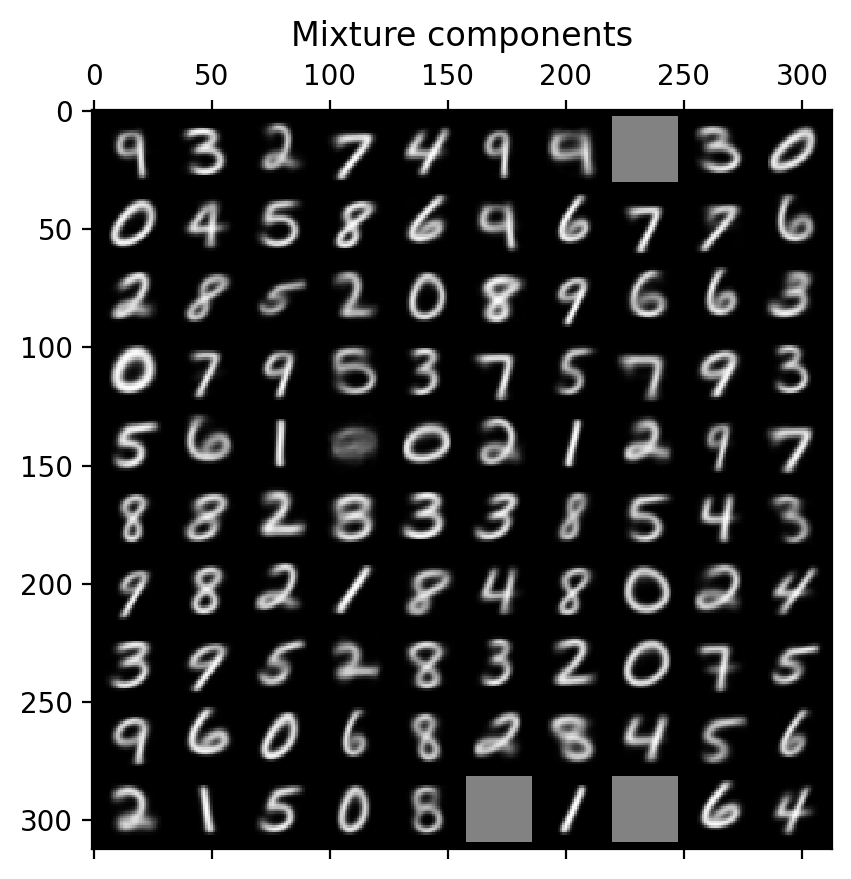

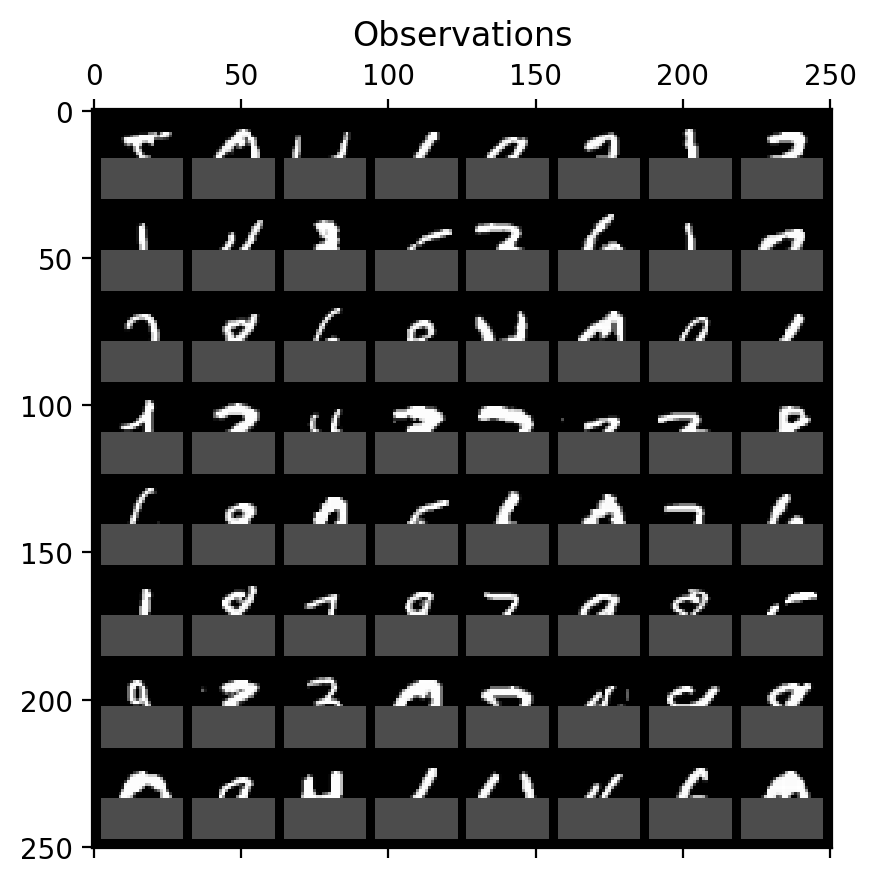

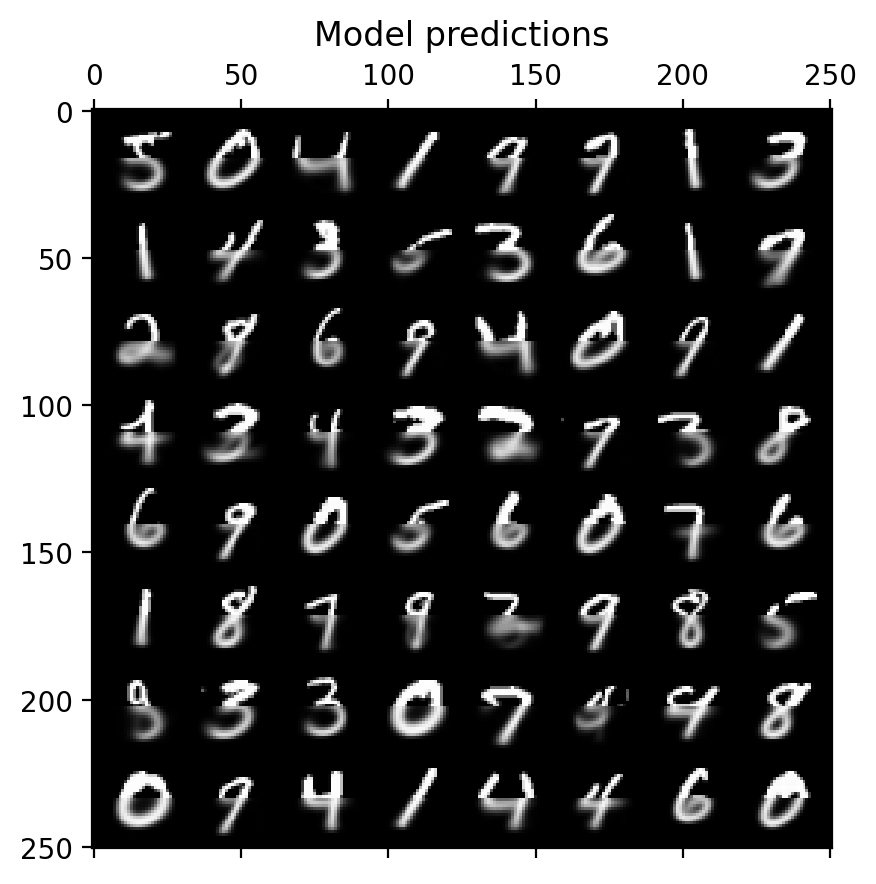

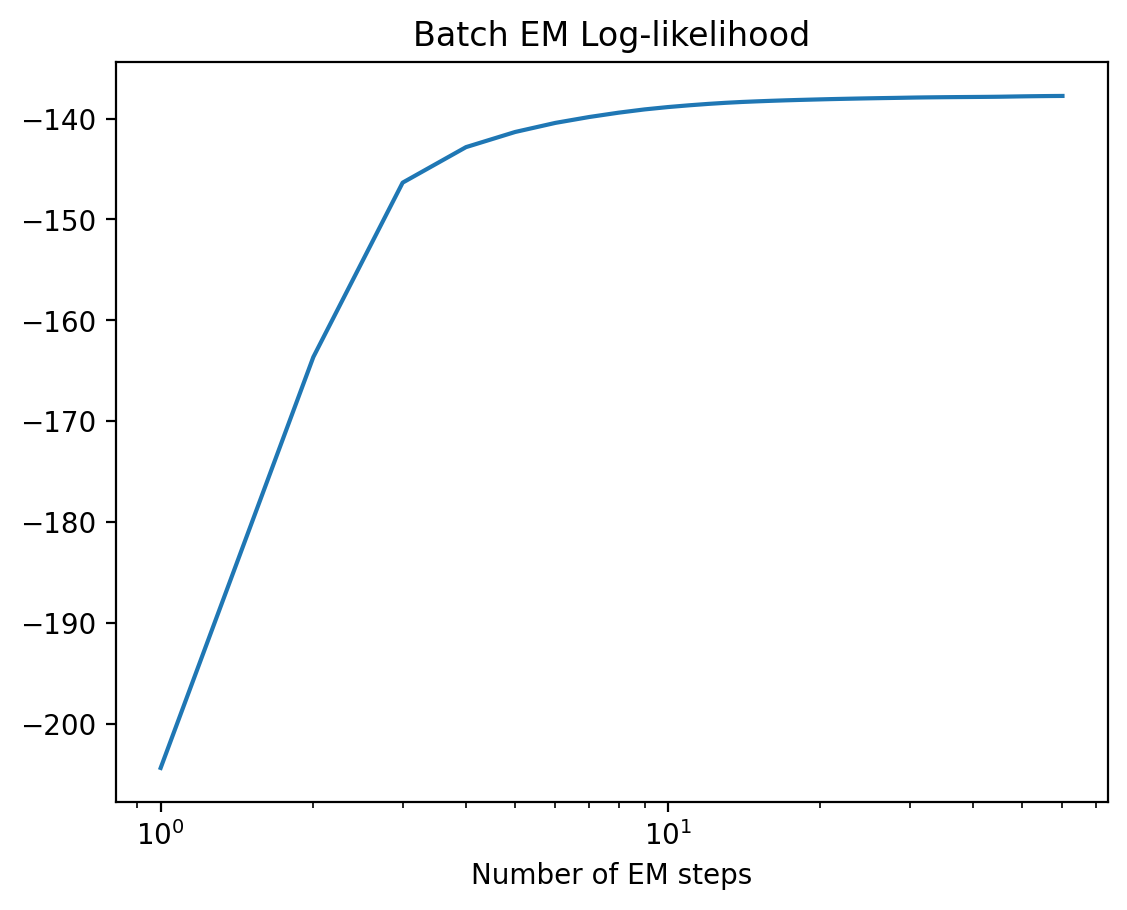

In [93]:
%%time

# this may take some time to finish, depending on your device
model, loglik_vals, time = train_with_em(
    num_components=100, 
    num_steps=60,
)

### Task 4B.3: Speeding up EM with Online Updates (10pt)

#### Background
So far, our Expectation-Maximization (EM) algorithm updates parameters by iterating over the entire dataset in each step. This is known as Batch EM. However, when dealing with large datasets, this approach can be slow and computationally expensive.

A more efficient alternative is Online EM, where:
- Instead of computing updates using all data points, we process mini-batches at a time.
- Model parameters are updated incrementally, allowing us to make progress without needing the full dataset.

This technique reduces computational cost and often speeds up convergence.

#### Key Idea: Stochastic Approximation
Instead of fully computing the standard EM updates:

$$
\mathbf{\pi}^{(t+1)} = \frac{\sum_{i=1}^{N} R^{(i)}}{N}
$$

we use an incremental update:

$$
\mathbf{\pi}^{(t+1)} = (1 - \eta_t) \mathbf{\pi}^{(t)} + \eta_t \cdot \frac{1}{B} \sum_{i \in \mathcal{B}} R^{(i)}
$$

where:
- $B$ is the mini-batch size (e.g., 1000 samples instead of the full dataset).
- $\eta_t$ is a learning rate that decreases over time to prevent instability:

$$
\eta_t = \frac{1}{t+1}
$$

This ensures that as the algorithm progresses, updates become smaller, allowing the parameters to stabilize.

The same update is applied to $\mathbf{\Theta}$ (pixel probabilities per cluster):

$$
\mathbf{\Theta}^{(t+1)} = (1 - \eta_t) \mathbf{\Theta}^{(t)} + \eta_t \cdot \frac{R^T X}{\sum R}
$$

#### Your Task: Implement Online EM
Complete the `train_with_online_em()` method for the online EM algorithm. Specifically, you will:
1. Use mini-batches instead of processing the entire dataset.
2. Implement a decaying learning rate \( \eta_t \).
3. Compare the convergence speed with Batch EM.



In [94]:
def train_with_online_em(num_components=100, num_steps=50, batch_size=1000, prior=None, draw_every=5):
    """
    Train the Mixture of Bernoullis model using online EM with masking.
    
    Args:
        num_components: Number of mixture components (clusters).
        num_steps: Total number of EM iterations.
        batch_size: Number of data points in each mini-batch.
        prior: Prior over parameters.
        draw_every: Frequency of visualization.
    
    Returns:
        model: Trained mixture model.
        loglik_vals: Log-likelihood at each iteration (for comparison).
        elapsed_time: Time taken for training.
    """
    import time

    if prior is None:
        prior = Prior.default_prior()

    # Load dataset
    X = util.read_mnist_images(TRAIN_IMAGES_FILE)
    X_test = util.read_mnist_images(TEST_IMAGES_FILE)
    num_data, num_pixels = X.shape

    # Create a mask that includes only the top half of pixels
    M = np.zeros(X.shape, dtype=int)
    M[:, :M.shape[1] // 2] = 1

    # Initialize model
    model = Model.random_initialization(prior, num_components, num_pixels)

    loglik_vals = []
    start_time = time.time()

    for t in range(1, num_steps + 1):
        # ##################################################################################
        #Populate batch_indices with a random batch
        #X_batch should contain that batch from X
        #M_batch should contain that batch from the mask
        batch_indices, X_batch, M_batch = None, None, None
        #! YOUR CODE STARTS HERE
        batch_indices = np.random.choice(num_data, size=batch_size, replace=False)
        X_batch = X[batch_indices]
        M_batch = M[batch_indices]
        #! YOUR CODE ENDS HERE
        
        #compute responsibilities using the E-step
        #R_batch contains the computed posterior
        R_batch = None

        #! YOUR CODE STARTS HERE
        R_batch = model.compute_posterior(X_batch, M_batch)
        #! YOUR CODE ENDS HERE

        # Adaptive learning rate
        eta_t = 1.56 / (t + 1)  # You may tune this later for better results
        
        #Update pi and theta (model.params.pi  and  model.params.theta )using the M-step updates
        #! YOUR CODE STARTS HERE
        model.params.pi = (1 - eta_t) * model.params.pi + eta_t * (1 / batch_size) * R_batch.sum(axis=0)
        model.params.theta = (1 - eta_t) * model.params.theta + eta_t * (R_batch.T @ X_batch) / (R_batch.sum(axis=0)[:, np.newaxis])
        #! YOUR CODE ENDS HERE

        # Compute log-likelihood
        loglik = model.log_likelihood(X) / num_data
        loglik_vals.append(loglik)

        if (t + 1) % draw_every == 0:
            print(f'Iteration {t+1}, Log-likelihood: {loglik:.4f}')
            model.visualize_components()
            model.visualize_predictions(X[:64, :], M[:64, :])  # Use the mask for visualization

            pylab.figure('Log-likelihood')
            pylab.clf()
            pylab.semilogx(np.arange(1, len(loglik_vals) + 1), loglik_vals)
            pylab.title('Online EM Log-likelihood')
            pylab.xlabel('Number of Online EM steps')
            pylab.draw()

    elapsed_time = time.time() - start_time

    print('Final training log-likelihood:', model.log_likelihood(X) / num_data)
    print('Final test log-likelihood:', model.log_likelihood(X_test) / X_test.shape[0])
    print(f"Time elapsed: {elapsed_time:.2f} seconds")

    return model, loglik_vals, elapsed_time

Iteration 5, Log-likelihood: -179.9493
Iteration 10, Log-likelihood: -156.6114
Iteration 15, Log-likelihood: -151.1564
Iteration 20, Log-likelihood: -148.8615
Iteration 25, Log-likelihood: -147.6896
Iteration 30, Log-likelihood: -146.9664
Iteration 35, Log-likelihood: -146.4782
Iteration 40, Log-likelihood: -146.1360
Iteration 45, Log-likelihood: -145.8775
Iteration 50, Log-likelihood: -145.6593
Iteration 55, Log-likelihood: -145.4953
Iteration 60, Log-likelihood: -145.3789
Final training log-likelihood: -145.35744083638676
Final test log-likelihood: -145.0441627679691
Time elapsed: 35.73 seconds
CPU times: user 3min 47s, sys: 23 s, total: 4min 10s
Wall time: 36.3 s


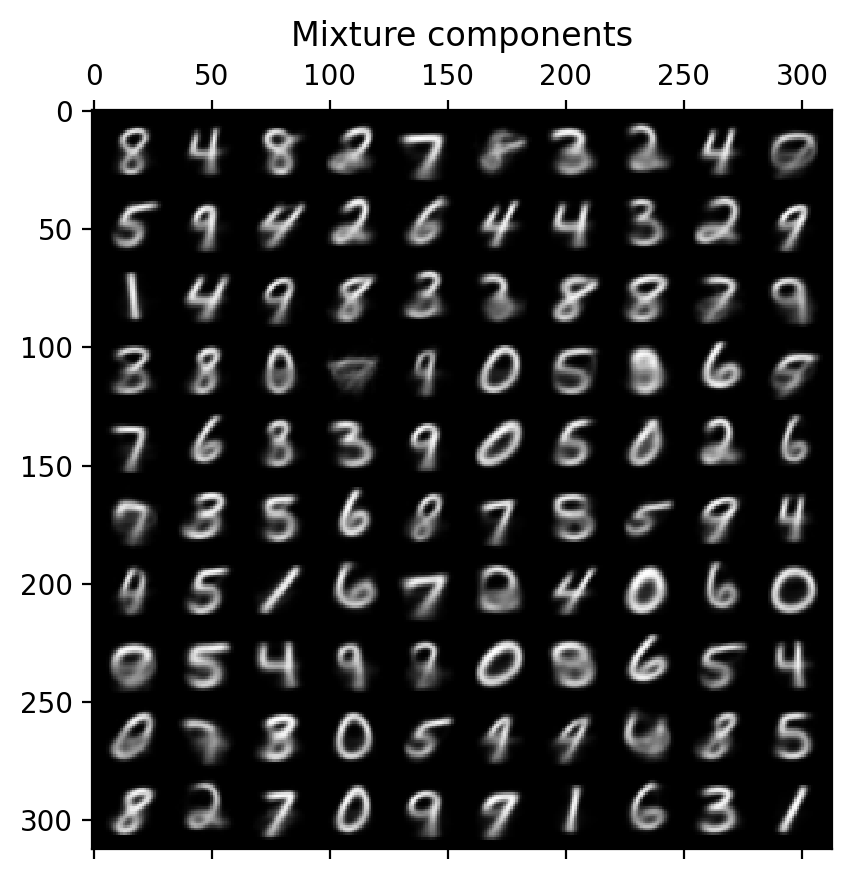

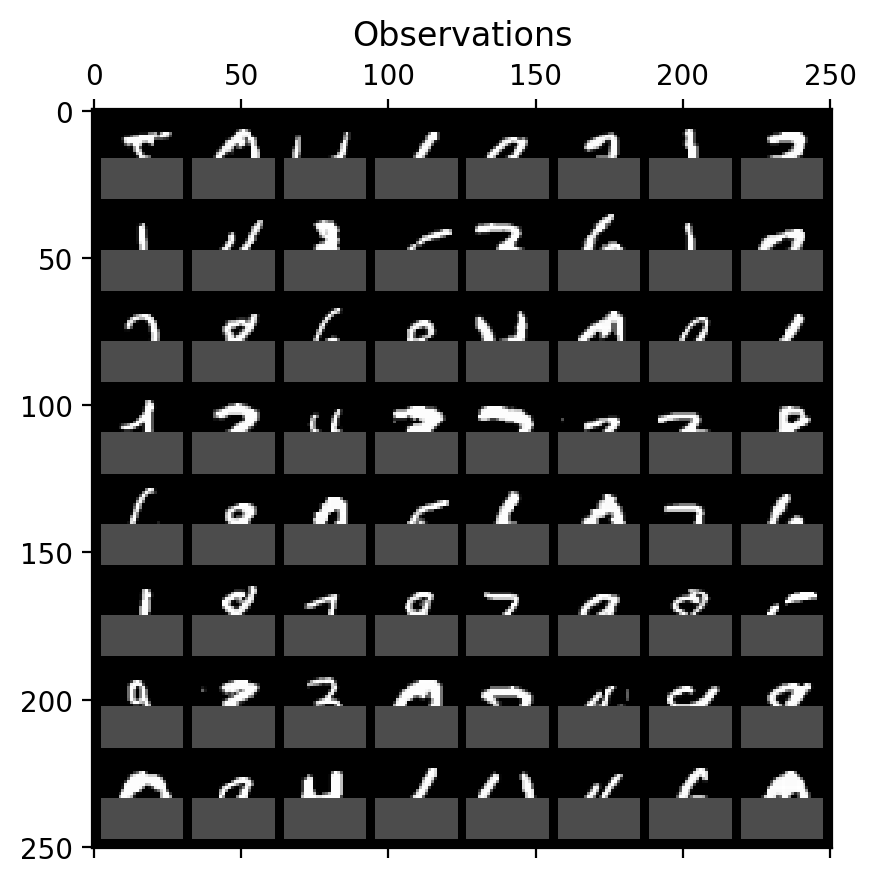

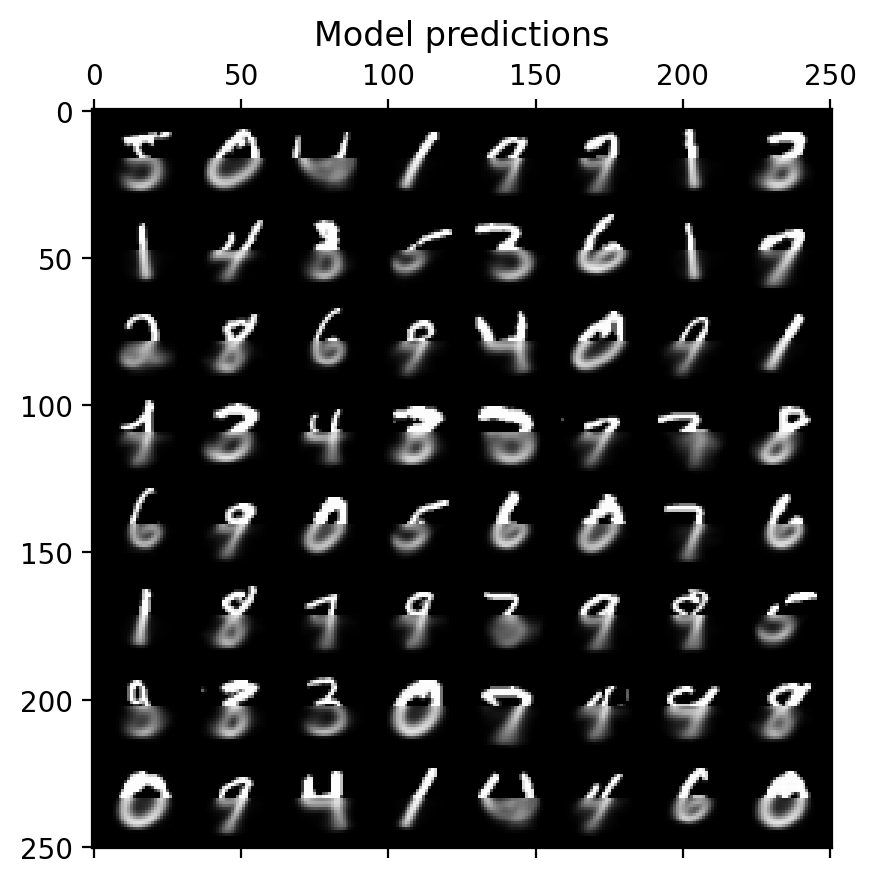

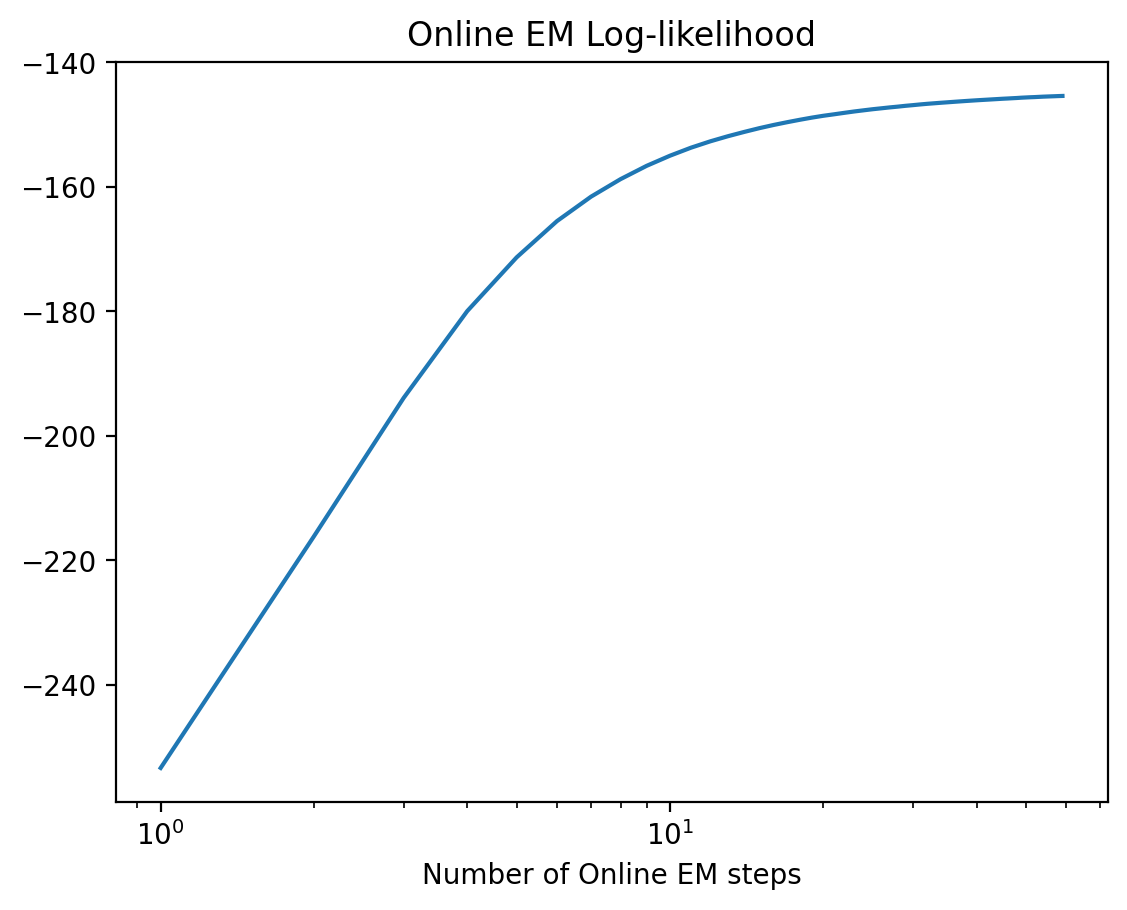

In [95]:
%%time

# No need to modify the code, but feel free to improve it if you'd like to.

# Run Online EM
online_model, online_loglik, online_time = train_with_online_em(
    num_components=100, 
    num_steps=60, 
    batch_size=5000,
)

Plot the log-likelihood curves to compare the convergence of Batch EM vs. Online EM.

In [96]:
!pip install seaborn

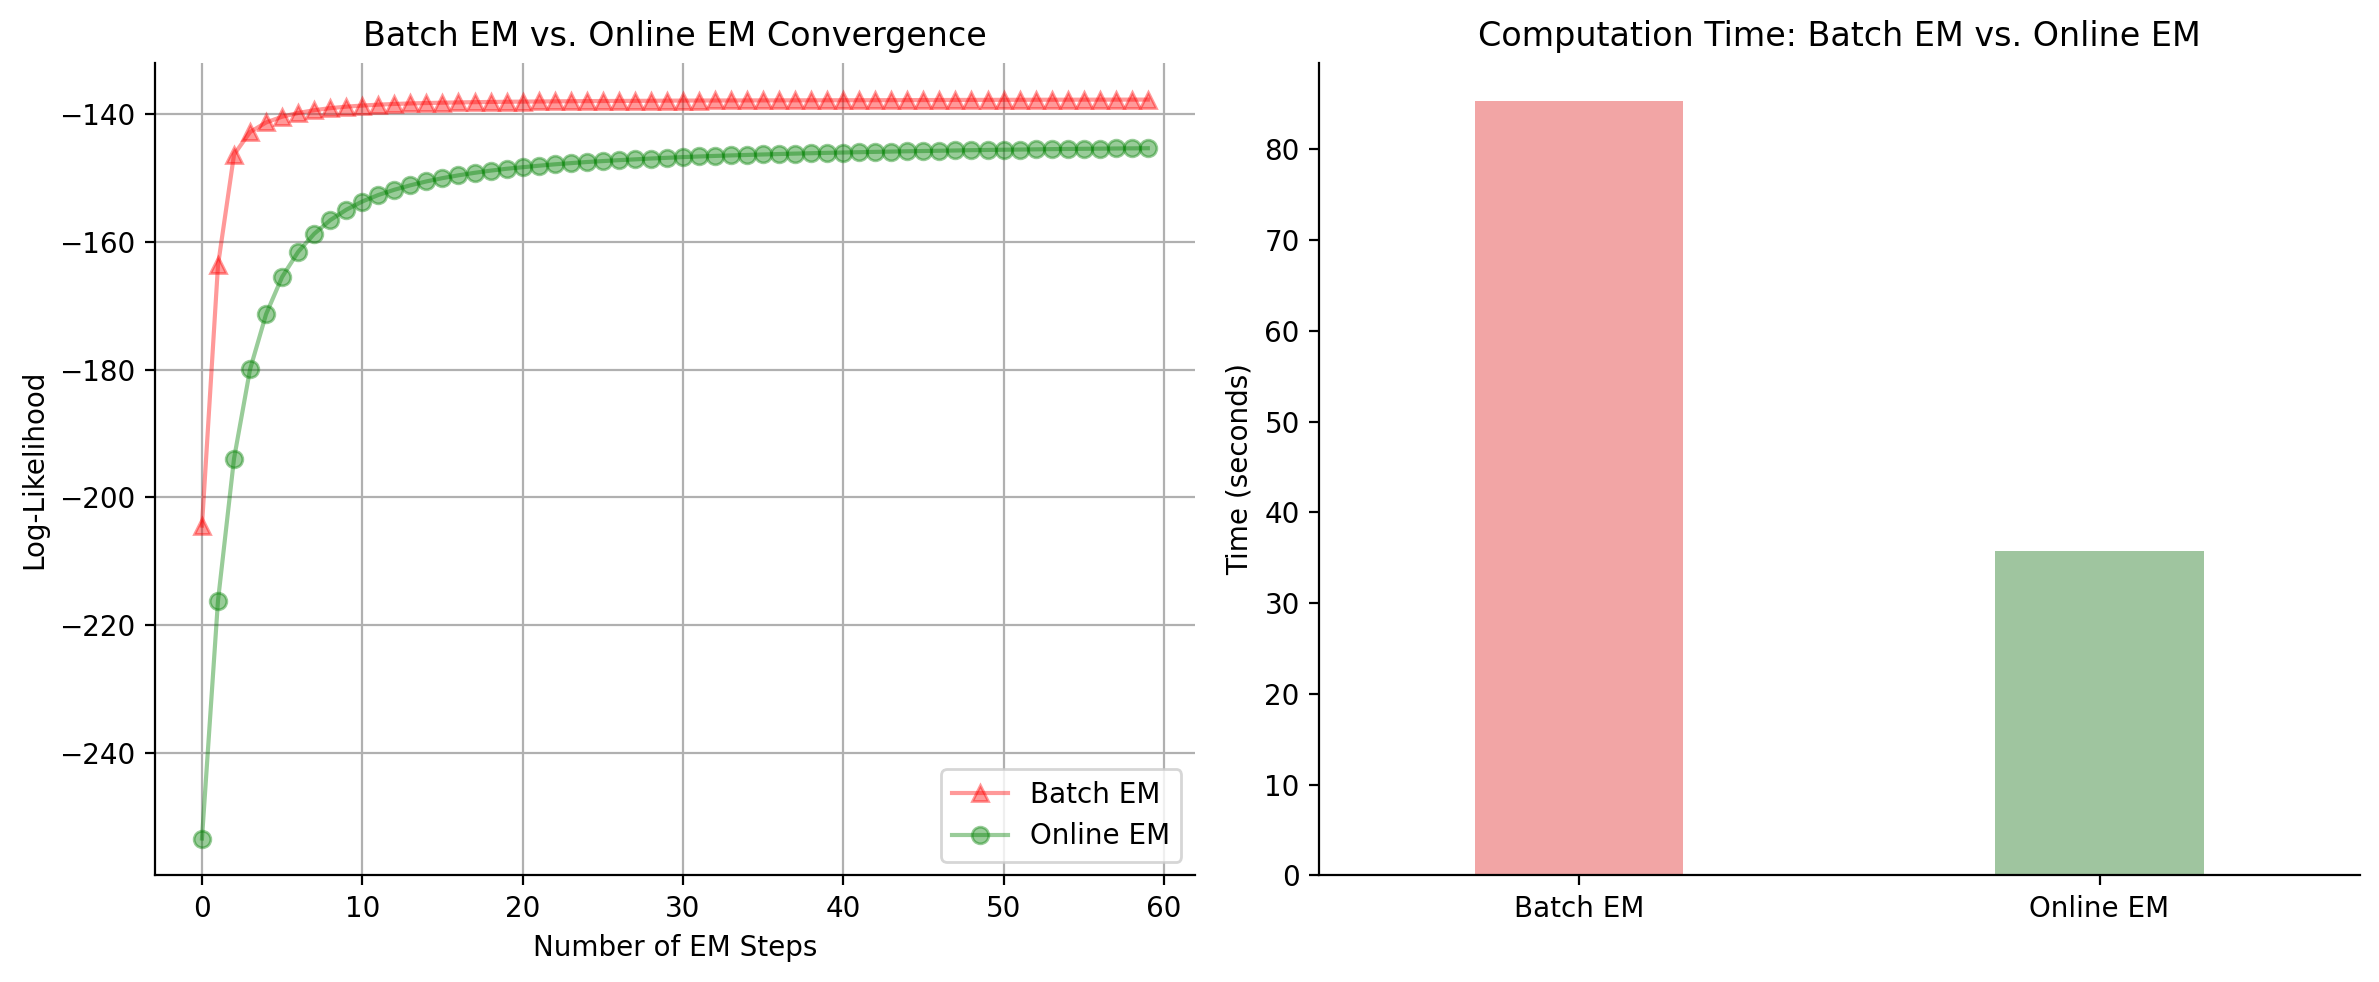

In [97]:
# No need to modify the code, but feel free to improve it if you'd like to.

import matplotlib.pyplot as plt
import seaborn as sea

# Data for bar plot
methods = ["Batch EM", "Online EM"]
times = [time, online_time]  # Use actual measured times from your runs

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Log-Likelihood Convergence
axes[0].plot(loglik_vals, label="Batch EM", linestyle="-", marker="^", color='red', alpha=0.4)
axes[0].plot(online_loglik, label="Online EM", linestyle="-", marker="o", color='green', alpha=0.4)
axes[0].set_xlabel("Number of EM Steps")
axes[0].set_ylabel("Log-Likelihood")
axes[0].set_title("Batch EM vs. Online EM Convergence")
axes[0].legend()
axes[0].grid(True)
sea.despine()

# Plot Computation Time Comparison
sea.barplot(x=methods, y=times, hue=methods, palette=["red", "green"], alpha=0.4, ax=axes[1], width=0.4)
axes[1].set_ylabel("Time (seconds)")
axes[1].set_title("Computation Time: Batch EM vs. Online EM")
sea.despine()

# Show the plots
plt.tight_layout()
plt.show()


Compare the performance of Batch EM and Online EM based on your results.  
- Summarize your key observations about their convergence behavior and efficiency.  
- Online EM starts with a lower log-likelihood than Batch EM. Why might this happen?  
- Given that Batch EM took `time` seconds and Online EM took `online_time` seconds, which method would you prefer, and under what circumstances?

`YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

`YOUR ANSWER ENDS HERE`

## Task 4C (Bonus): Comparing Gaussian Bayes Classifer, Fisher's LDA, Logistic Regression (20pts)

### Background

In this section, we're going to compare generative and discriminative methods on various binary datasets. First, a reminder on the theoretical background:

**1. Gaussian Bayes Classifier (GBC):**
GBC models the class label distribution as $(y = +1) \sim Bernoulli(p_+)$, and model features as multivariate Gaussians:
$$
(\mathbf{x} | y = +1) \sim \mathcal{N} (\mathbf{x}; \mu_+, \Sigma_+), \quad (\mathbf{x} | y = -1) \sim \mathcal{N} (\mathbf{x}; \mu_-, \Sigma_-) 
$$

The MLE for the parameters are in the notes, and will be repeated in the subsections below. Note that Gaussian Naive Bayes (as per Part A) is simply the case where the covariance matrices $\Sigma_+$ and $\Sigma_-$ are diagonal. 

**2. Fisher's LDA:** (Henceforth, just LDA) Same as GBC, with the additional assumptions that $p_+ = 1/2$ and $\Sigma_+ = \Sigma_- = \Sigma$.

**3. Logistic Regression:**
We seek to minimize the empirical logistic loss: 

$$
L = \frac{1}{n} \sum_{i = 1}^n \ln(1 + \exp(- y_i \mathbf{w}^\top \mathbf{x}_i))
$$


### Summary of tasks
At a high level, your task in this section is to implement the above 4 methods and see which method works better on which dataset, as well as the impact of having a bigger training set on these methods and datasets.

### Starter Code

Some basic libraries are imported here for you. Note the linear algebra tools we import from `scipy.linalg`.

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from matplotlib.colors import ListedColormap
from scipy.linalg import sqrtm, pinv, eigvalsh
from sklearn.model_selection import train_test_split
np.seterr(over='ignore', under='ignore')


{'divide': 'warn', 'over': 'ignore', 'under': 'ignore', 'invalid': 'warn'}

The class `Classifier` implements the `score` function.

In [99]:
class Classifier:
    def predict(self,X):
        raise NotImplementedError
    def score(self,X,y):
        """Accuracy rate"""
        return np.mean(self.predict(X)==y)

The class `Gaussian2DMix` contains information of a binary Gaussian mixture. We will use this base class for both learning a dataset (assigning means, covariance matrices and priors to learned parameters) and generating a dataset (generate points with manually entered parameters).

Note that throughout, we use index 0 for the label -1, and index 1 for the label +1.

In [100]:
LABELS = [-1, 1]
class Gaussian2DMix(Classifier):
    """ Represents a mixture of Gaussians, with one label per Gaussian. """
    def __init__(self,
                 mus=[np.array([-1,0]),np.array([1,0])],
                 Sigmas=[np.eye(2), np.eye(2)],
                 ps=None,
                 labels=LABELS):
        """
        Instantiate the mixture based on specified parameters
        Args:
            mus: an array of length 2 of the means.
            Sigmas: an array of length 2 of the covariance matrices.
            ps: an array of length 2 over the the priors (should add up to 1).
        """
        if ps is None: # default to uniform over the components
            ps = np.array([1/len(labels)]*len(labels))
        self.mus=mus
        self.Sigmas=Sigmas
        self.ps=ps
        self.labels=labels

    def generate(self,m):
        """
        Generate m samples from the mixture
        Returns: (X, y)
            - X.shape = (m, 2)
            - y.shape = (m,)
        """
        # Pick m class labels from priors
        y = random.choice(self.labels, p=self.ps, size=m)
        x = np.empty((m, 2))
        for label, mu, Sigma in zip(self.labels, self.mus, self.Sigmas):
            thism = sum(y == label)
            # Generate x from p(x | y)
            x[y == label] = random.randn(thism, 2) @ sqrtm(Sigma) + mu
        return x,y
    
    def discriminant(self, X):
        raise NotImplementedError
    
    def predict(self, X):
        return np.sign(self.discriminant(X))

A scatter plot helper function is provided for you. Note that -1 labels are assigned the color red, +1 labels are assigned the color blue.

In [101]:
def scatter_plot(X, y, cmap_fg = {-1:'#FF0000', 1:'#0000FF'}, **plot_kwargs):
    labels = np.unique(y)
    plt.figure(figsize=(8, 6))
    for l in labels:
        l_idxs = np.where(y == l)
        plt.scatter(X[l_idxs, 0], X[l_idxs, 1], label=l, c=cmap_fg[l], **plot_kwargs)
    plt.legend()

### The datasets

We're going to investigate 4 binary datasets generated from various 2D Gaussian mixtures. You should not modify any of the prescribed parameters below. For each dataset, 200 samples are visualized below.

#### Source 1. "Standard"

Source 1 data is generated from
$$
\mu_- = \begin{pmatrix}
-1 \\
0
\end{pmatrix}, \mu_+ = \begin{pmatrix}
1 \\
0
\end{pmatrix}, \Sigma_- = \Sigma_+ = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}, p_+ = \frac{1}{2}
$$

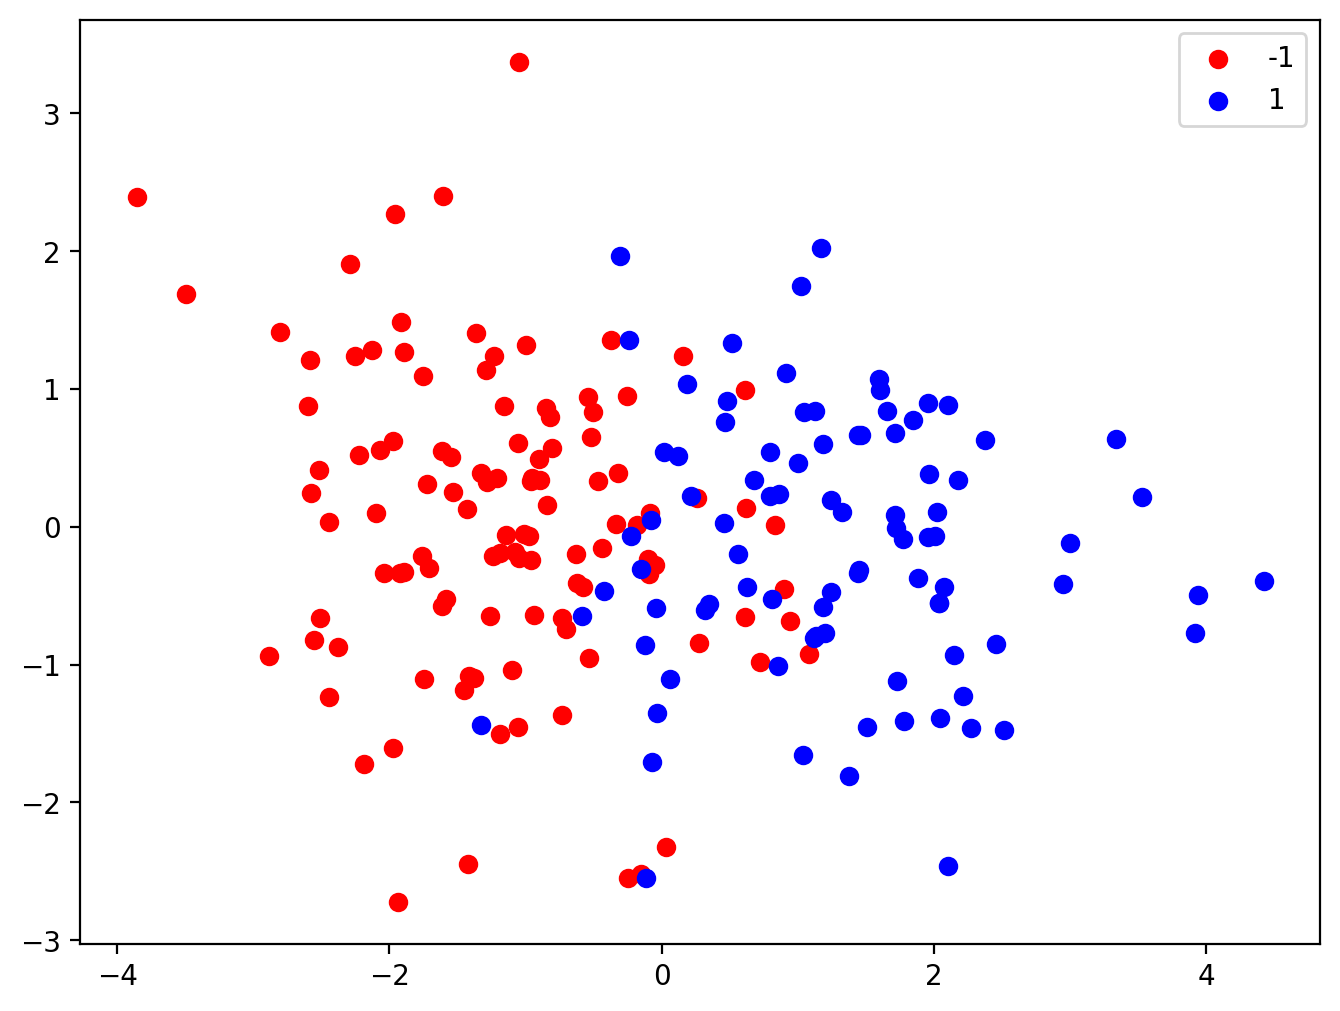

In [102]:
source_1 = Gaussian2DMix(mus = np.array([[-1, 0], [1, 0]])).generate
scatter_plot(*source_1(200))

#### Source 2. "Skewed"

Source 2 data is generated from
$$
\mu_- = \begin{pmatrix}
-1 \\
0
\end{pmatrix}, \mu_+ = \begin{pmatrix}
2 \\
0
\end{pmatrix}, \Sigma_- = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}, \Sigma_+ = \begin{pmatrix}
3 & 2.5 \\
2.5 & 3
\end{pmatrix},  p_+ = \frac{1}{2}
$$

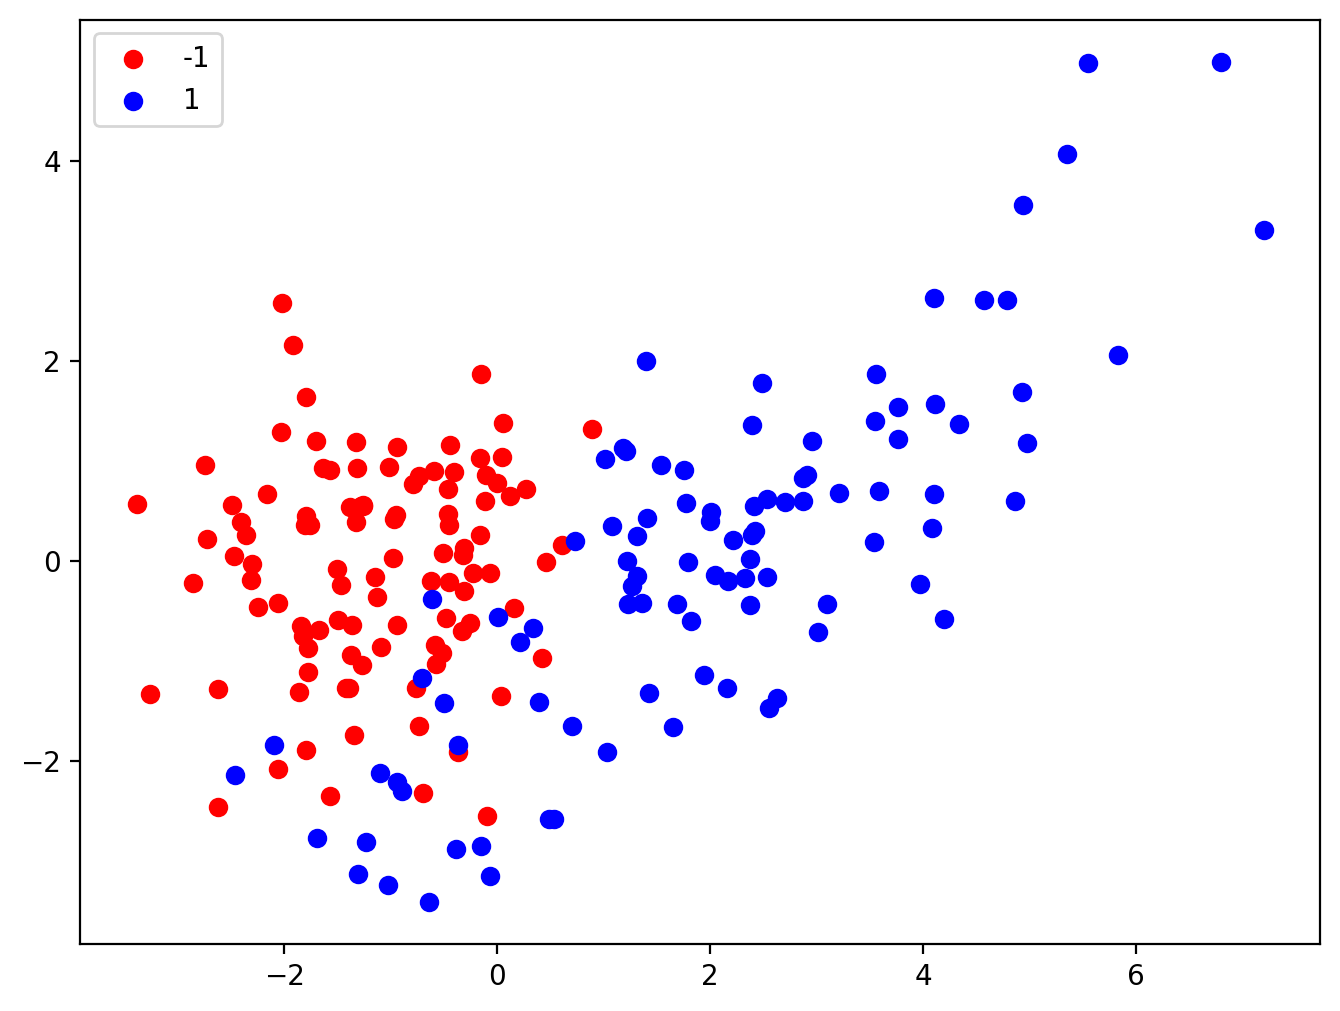

In [103]:
source_2 = Gaussian2DMix(mus = np.array([[-1, 0],
                                         [2, 0]]), 
                         Sigmas=[np.eye(2),np.array([[3, 2.5],
                                                     [2.5, 3]])]).generate

scatter_plot(*source_2(200))

#### Source 3: "Horizontal/Vertical"

Source 3 data is generated from
$$
\mu_- = \begin{pmatrix}
0 \\
0
\end{pmatrix}, \mu_+ = \begin{pmatrix}
10 \\
0
\end{pmatrix}, \Sigma_- = \begin{pmatrix}
0.49 & 0 \\
0 & 100
\end{pmatrix}, \Sigma_+ = \begin{pmatrix}
36 & 0 \\
0 & 0.04
\end{pmatrix},  p_+ = \frac{1}{2}
$$

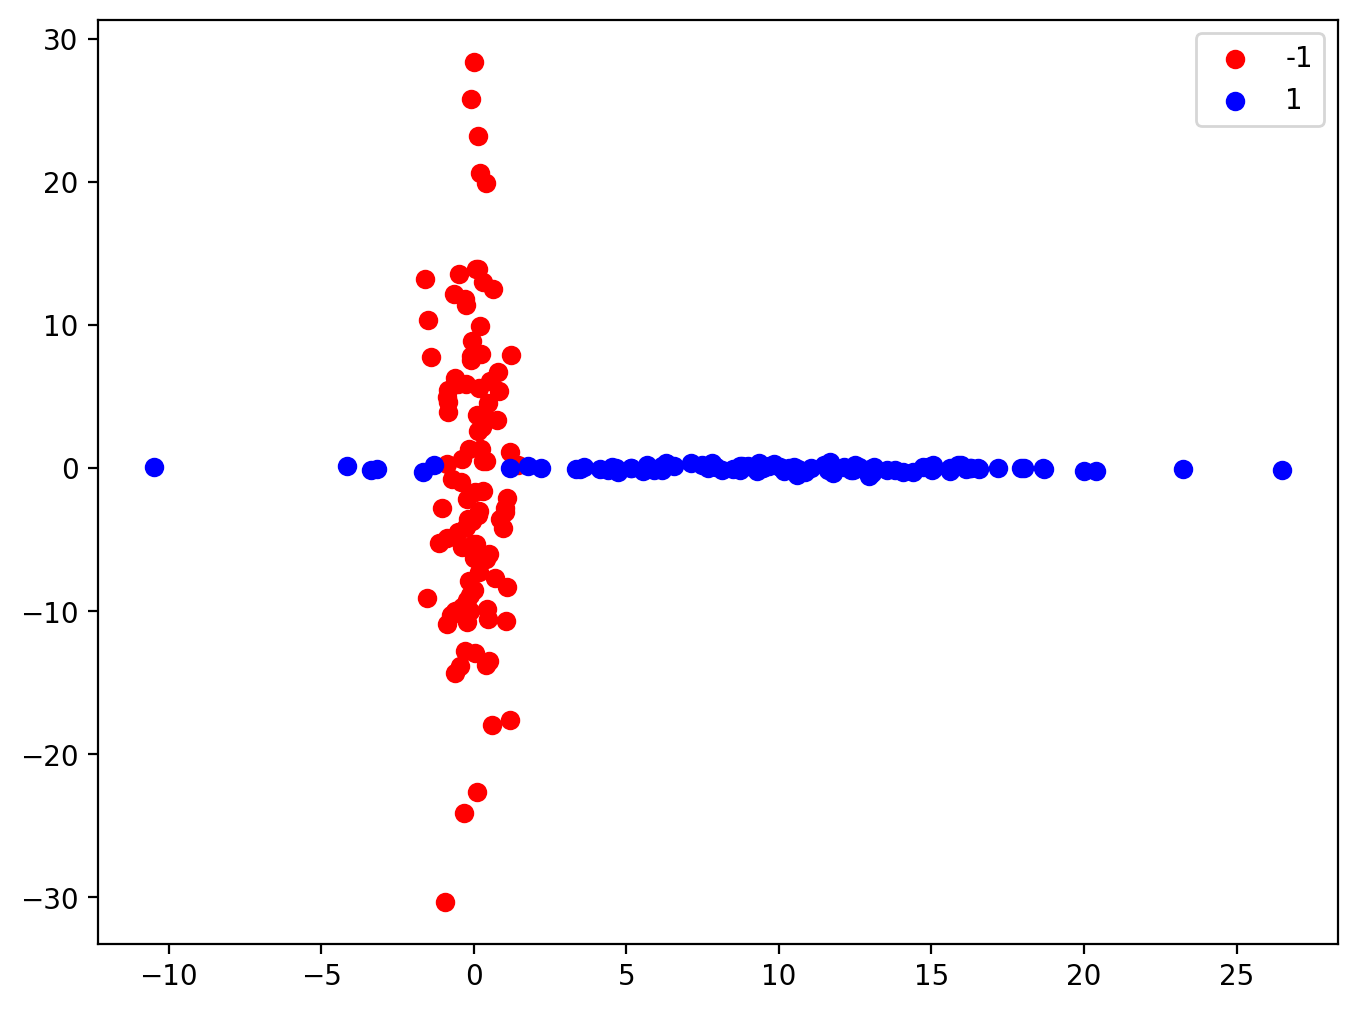

In [104]:
source_3 = Gaussian2DMix(mus = np.array([[0, 0],
                                         [10, 0]]),
                         Sigmas = [ np.diag([0.7, 10]) ** 2,
                                    np.diag([6, 0.2]) ** 2]).generate

scatter_plot(*source_3(200))

#### Source 4: "Class Imbalance"

Source 4 data is generated from
$$
\mu_- = \begin{pmatrix}
-1 \\
0
\end{pmatrix}, \mu_+ = \begin{pmatrix}
1 \\
0
\end{pmatrix}, \Sigma_- = \Sigma_+ = \begin{pmatrix}
1 & 0 \\
0 & 1
\end{pmatrix}, p_+ = 0.2
$$

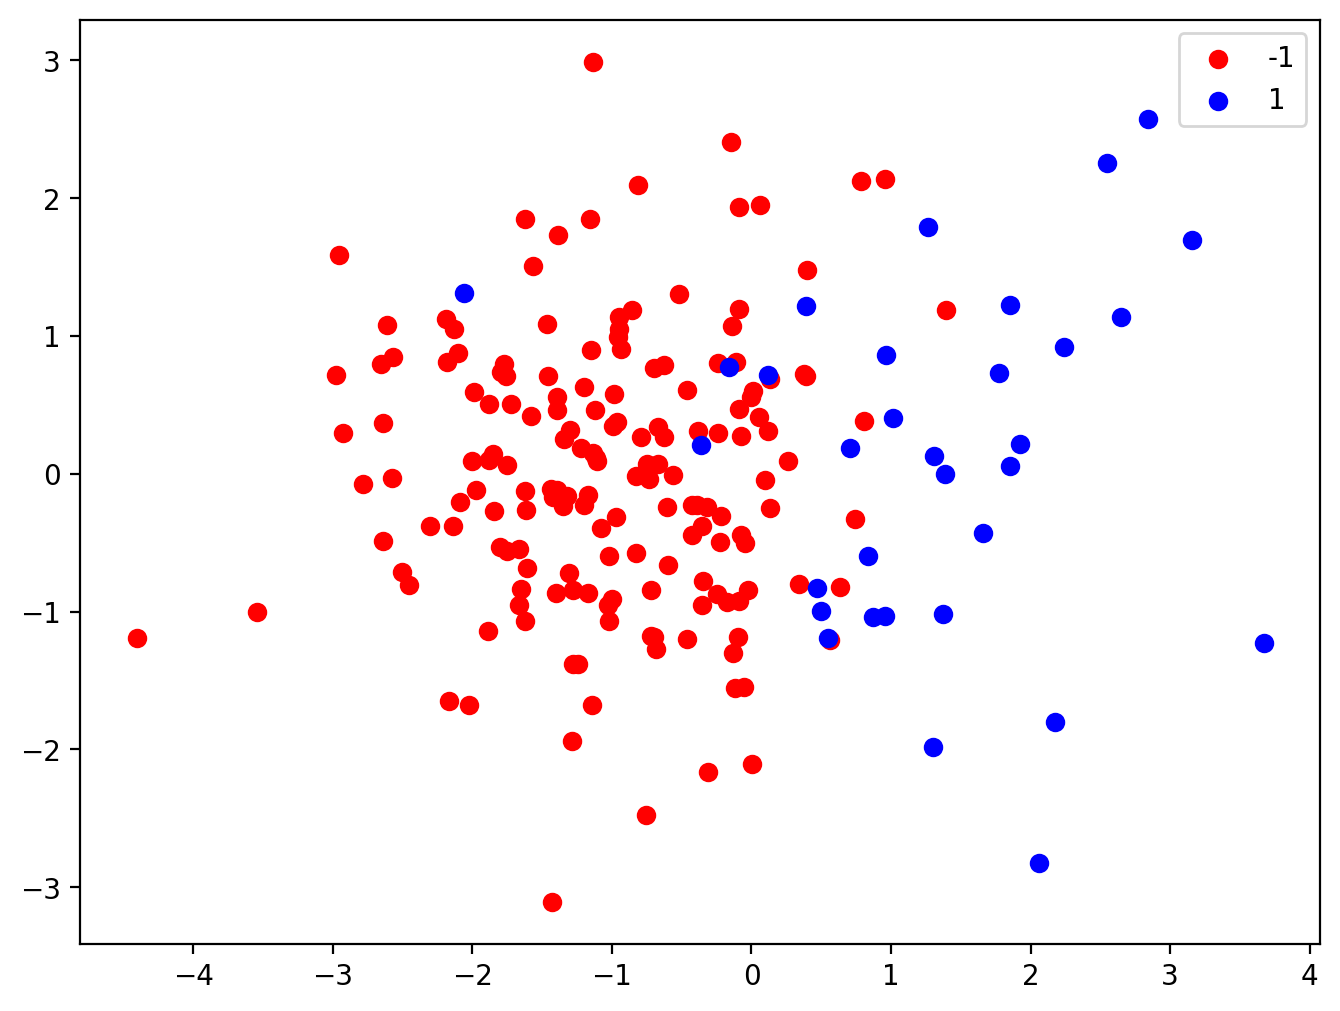

In [105]:
source_4 = Gaussian2DMix(mus = np.array([[-1, 0],
                                         [1, 0]]), ps=[0.8, 0.2]).generate

scatter_plot(*source_4(200))

A plotting utility function is provided. Note that it plots training data, and takes in a trained classifier `clf` that implements the ``predict`` method, and plots the test data along with the classifier's prediction.

In [106]:
def plot_decision_boundary(clf, X_train, y_train, X_test, y_test,  ax=None,
                           cmap_bg = ListedColormap(['#FFAAAA', '#AAAAFF']), cmap_fg = {-1:'#FF0000', 1:'#0000FF'}):
    """
    Plots the decision boundary of the given classifier on training and testing points.
    Colors the training points with true labels, and shows the incorrectly and correctly predicted test points.
    """
    if ax is None:
        fig, ax = plt.figure(figsize=(8, 6))
    X, y = np.vstack([X_train, X_test]), np.hstack([y_train.flatten(), y_test.flatten()])
    labels = np.unique(y)
    x_min, x_max = np.min(X, axis=0), np.max(X, axis=0)
    
    # Create a mesh of points
    x1s = np.linspace(x_min[0], x_max[0], 100)
    x2s = np.linspace(x_min[1], x_max[1], 100)
    xx1, xx2 = np.meshgrid(x1s, x2s)
    Z = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])

    # Put the result into a color plot
    Z = Z.reshape(xx1.shape)
    ax.pcolormesh(xx1, xx2, Z, cmap=cmap_bg, shading='auto')

    # Plot training points
    for l in labels:
        l_idxs = np.where(y_train == l)
        ax.scatter(X_train[l_idxs, 0], X_train[l_idxs, 1], label=f'train/{l}', c=cmap_fg[l], marker='.')
    
    # Plot test points
    y_test_predict = clf.predict(X_test)
    for l in labels:
        # Mark the wrong ones
        wrong_idxs = np.where((y_test == l) & (y_test_predict != y_test))
        ax.scatter(X_test[wrong_idxs, 0], X_test[wrong_idxs, 1], label=f'test/should be {l} (wrong)', c=cmap_fg[l], marker='x', s=100)

        # Plot the correct ones
        corr_idxs = np.where((y_test_predict == l) & (y_test_predict == y_test))
        ax.scatter(X_test[corr_idxs, 0], X_test[corr_idxs, 1], label=f'test/predicted {l} (correct)', c=cmap_fg[l], marker='+', s=50)
        
    ax.set_xlim(xx1.min(), xx1.max())
    ax.set_ylim(xx2.min(), xx2.max())
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Decision boundary\nShaded regions show what the label clf would predict for a point there')
    plt.legend(title='label', bbox_to_anchor=(1.04, 1), loc='upper left')


### Task 4C.1: GBC and LDA (5pts)

#### Your Task:
Implement the GBC and LDA classifiers **through the use of a discriminant function $r(\mathbf{x})$**.

Recall that 
$$
P(y = +1 | \mathbf{x}) = \frac{1}{1 + e^{-r(\mathbf{x})}}
$$
and the prediction is simply $\hat{y} = sign(r(\mathbf{x}))$.

For GBC, an analysis similar to the one done in class yields

$$
r(\mathbf{x}) = \frac{1}{2} \mathbf{x}^\top (\Sigma_-^{-1} - \Sigma_+^{-1}) \mathbf{x} + \mathbf{x}^\top (\Sigma_+^{-1} \mu_+ - \Sigma_-^{-1} \mu_-) + (\ln \frac{p_+}{1 - p_+} - \frac{1}{2} \mu_+^\top \Sigma_+^{-1} \mu_+ + \frac{1}{2} \mu_-^\top \Sigma_-^{-1} \mu_- - \frac{1}{2} \ln \det (\Sigma_+) + \frac{1}{2} \ln \det (\Sigma_-))
$$

We emphasize that this is linear in the quadratic feature space.

For LDA, 

$$
r(\mathbf{x}) = \mathbf{x}^\top (\Sigma_- (\mu_+ - \mu_-)) + (\ln \frac{p_+}{1 - p_+} - \frac{1}{2} \mu_+^\top \Sigma^{-1} \mu_+ + \frac{1}{2} \mu_-^\top \Sigma^{-1} \mu_-)
$$

where we note that this is just the simplification of the above when $\Sigma_+ = \Sigma_- = \Sigma$, and $p_+ = 1 - p_+ = 0.5$. We emphasize that this is simply linear in $\mathbf{x}$.

In the implementations below, you are highly encouraged to use matrix operations for efficiency. You should first implement `fit`, which will set the parameters of the 2D Gaussian Mixture to their MLE; and then implement `discriminant` using these learned parameters. Though it is possible, you should not implement this in the probabilistic sense as per Part A -- the point of this task is to flesh out the nature of the underlying discriminant.

**Report**: include code snippets of your implementation, and describe your code. You do not need to include formulas for $r(\mathbf{x})$.

In [107]:
def plogdeth(A):
    """ Stably returns the log of the determinant of a symmetric matrix A. """
    v = eigvalsh(A)
    return np.sum(np.log(v[~np.isclose(v,0)]))


class GBC(Gaussian2DMix):
    def fit(self, Xs, ys):
        # Populate self.ps, self.mus, and self.Sigmas based on the data
        # Hint: use np.mean and np.cov to compute these statistics
        #! YOUR CODE STARTS HERE
        mu_plus = np.mean(Xs[ys == 1], axis=0)
        mu_minus = np.mean(Xs[ys == -1], axis=0)
        self.mus = np.array([mu_minus, mu_plus])
        X_neg = Xs[ys == -1]
        X_pos = Xs[ys == 1]
        Sigma_neg = np.cov(X_neg, rowvar=False)
        Sigma_pos = np.cov(X_pos, rowvar=False) 
        self.Sigmas = np.array([Sigma_neg, Sigma_pos])
        p_neg = np.sum(ys == -1) / len(ys)
        p_pos = np.sum(ys == 1) / len(ys)
        self.ps = np.array([p_neg, p_pos])
        #! YOUR CODE ENDS HERE

    def discriminant(self, X):
        mu_neg, mu_pos = self.mus[0], self.mus[1]
        Sigma_neg, Sigma_pos = self.Sigmas[0], self.Sigmas[1]
        p_neg, p_pos = self.ps[0], self.ps[1]

        Sigma_neg_inv = pinv(Sigma_neg)
        Sigma_pos_inv = pinv(Sigma_pos)
        log_det_neg = plogdeth(Sigma_neg)
        log_det_pos = plogdeth(Sigma_pos)

        r_x = None
        #! YOUR CODE STARTS HERE
        A = (Sigma_neg_inv - Sigma_pos_inv)            
        b = (Sigma_pos_inv @ mu_pos - Sigma_neg_inv @ mu_neg) 
        const = float(
            np.log(p_pos / p_neg)
            - 0.5*(mu_pos.T @ Sigma_pos_inv @ mu_pos - mu_neg.T @ Sigma_neg_inv @ mu_neg)
            + 0.5*(log_det_neg - log_det_pos)
        )
        X = np.asarray(X)
        if X.ndim == 1:
            X = X[None, :]                              
        quad = 0.5 * np.einsum('ni,ij,nj->n', X, A, X) 
        lin  = X @ b                                     
        r_x = quad + lin + const                         
        #! YOUR CODE ENDS HERE
        return r_x

class LDA(Gaussian2DMix):
    def fit(self, Xs, ys):
        # Populate self.ps, self.mus, and self.Sigmas based on the data
        #! YOUR CODE STARTS HERE
        mu_plus = np.mean(Xs[ys == 1], axis=0)
        mu_minus = np.mean(Xs[ys == -1], axis=0)
        self.mus = np.array([mu_minus, mu_plus])
        self.Sigmas = np.array([np.cov(Xs, rowvar=False)] * 2)
        p_pos = np.sum(ys == 1) / len(ys)
        p_neg = np.sum(ys == -1) / len(ys)
        self.ps = np.array([p_neg, p_pos])
        #! YOUR CODE ENDS HERE
        
    def discriminant(self, X):
        w, b = None, None
        #! YOUR CODE STARTS HERE
        assert self.Sigmas[0].shape == self.Sigmas[1].shape, "Covariance matrices must be the same for LDA"
        Sigma_inv = pinv(self.Sigmas[0])
        mu_neg = self.mus[0]
        mu_pos = self.mus[1]
        p_pos = self.ps[1]
        w = Sigma_inv @ (mu_pos - mu_neg)
        b = 1/2 * (mu_neg.T @ Sigma_inv @ mu_neg - mu_pos.T @ Sigma_inv @ mu_pos) + np.log(p_pos / (1 - p_pos))
        #! YOUR CODE ENDS HERE
        return X @ w + b

### Task 4C.2: LogisticRegression (5pts)

#### Your Task:

Implement the `LogisticRegression` classifier below. Note the structure of the class, and that we're using `scipy` to perform the optimization for us.

**Report**: just include code snippets of your implementation of `LogisticReg`. No need to justify/describe.

In [108]:
from scipy.optimize import minimize
class ERMLinearClassifier(Classifier):
    def fit(self, Xs, ys):
        # Append a column of 1s to the feature matrix
        Xs = np.hstack([Xs, np.ones((Xs.shape[0], 1))])
        yX = ys[:, np.newaxis] * Xs
        m, d = yX.shape

        def training_obj(w):
            return self.loss_func(yX, w)
        
        def training_grad(w):
            # Returns the derivative of the loss wrt w
            return self.loss_derivative(yX, w)
        
        minimization = minimize(training_obj, np.zeros(d), jac=training_grad)
        self.w = minimization.x
        self.b = self.w[-1]
        self.w = self.w[:-1]
    
    def predict(self, X):
        return np.sign(X @ self.w + self.b)
        

class LogisticReg(ERMLinearClassifier):
    def loss_func(self, yX, w):
        #! YOUR CODE STARTS HERE
        n = yX.shape[0]
        loss = (1/n) * np.sum(np.log(1 + np.exp(-yX @ w)))
        return loss
        #! YOUR CODE ENDS HERE

    def loss_derivative(self, yX, w):
        #! YOUR CODE STARTS HERE
        n = yX.shape[0]
        z = yX @ w                           
        s = 1 / (1 + np.exp(z))              
        grad = -(1/n) * (yX * s[:, None]).sum(axis=0)
        return grad
        #! YOUR CODE ENDS HERE

### Task 4C.3: Analysis (5pts)

Finally we're ready for some analysis. The code below is provided for you to compare the decision boundaries that each model draws for each dataset.

**Report:** Include the generated plot, and discuss/answer the following questions:

- For each dataset, give qualitative remarks about the decision boundary that each model draws.
- Relate your qualitative remarks to the linear separability (or lack thereof) of the datasets, as well as the structure of the discriminant/prediction functions. 
- Relate your qualitative remarks to the assumptions made by GBC and LDA respectively. On which dataset did their (qualitative) performance/boundary differ?

`YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

`YOUR ANSWER ENDS HERE`

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

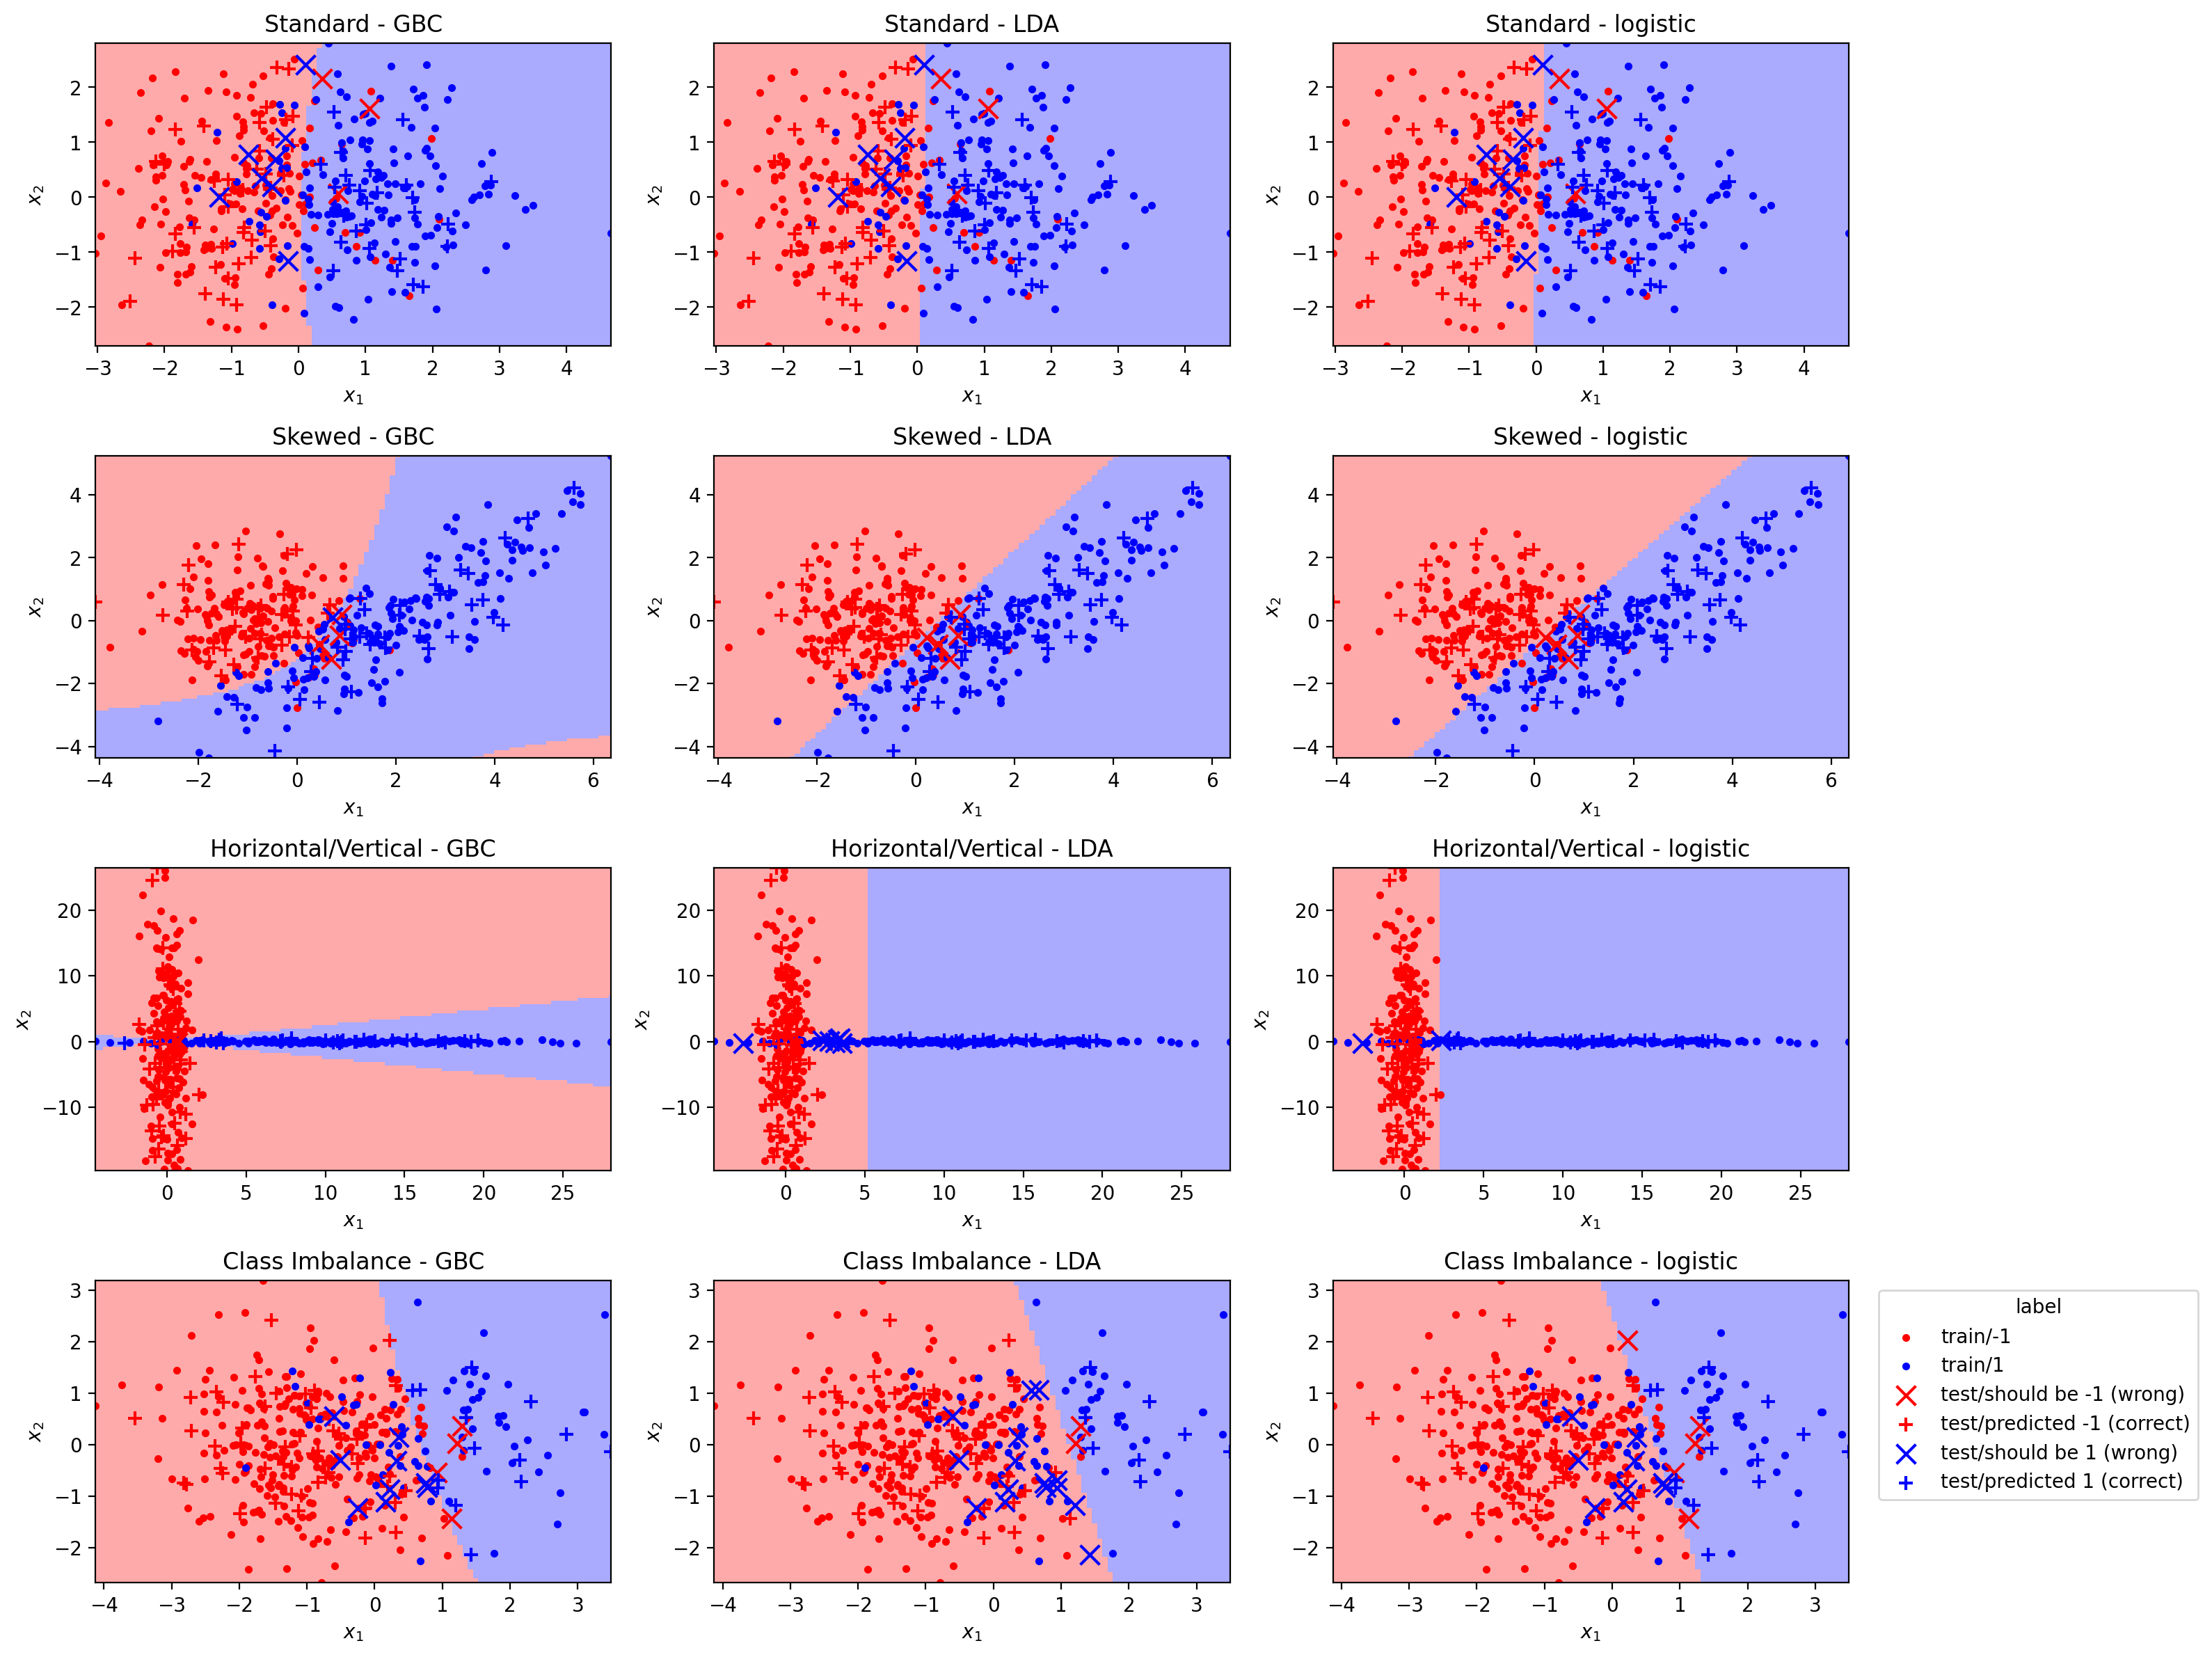

In [109]:
methods = { 'GBC': GBC(), 'LDA': LDA(), 'logistic': LogisticReg()}

sources = {'Standard': source_1, 'Skewed': source_2, 'Horizontal/Vertical': source_3, 'Class Imbalance': source_4}

fig, axes = plt.subplots(len(sources), len(methods), figsize=(16, 12))

for row_idx, (source_name, source_func) in enumerate(sources.items()):
    X, y = source_func(400)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    for col_idx, (method_name, method) in enumerate(methods.items()):
        ax = axes[row_idx, col_idx]
        method.fit(X_train, y_train)
        plot_decision_boundary(method, X_train, y_train, X_test, y_test, ax)
        ax.set_title(f"{source_name} - {method_name}")

plt.tight_layout()
plt.show()

### Task 4C.4: Accuracy against size of training set (5pts)

Some code is provided for you to test the performance of each model as the size of the training data increases. You do not need to modify the code.

**Report:** In your report, include the generated plot and answer the following questions:
1. Roughly explain the structure of what the code is doing. In particular, point out what stochasticity/variance the `n_reps` is trying to alleviate, and where it comes from.
2. Qualitatively discuss the performance between the models. For each dataset, explain the discrepancy/similarity between their performances.
3. Discuss the performance of each model as size of training data increases.

`YOUR ANSWER STARTS HERE`

- `YOUR ANSWER HERE`

`YOUR ANSWER ENDS HERE`

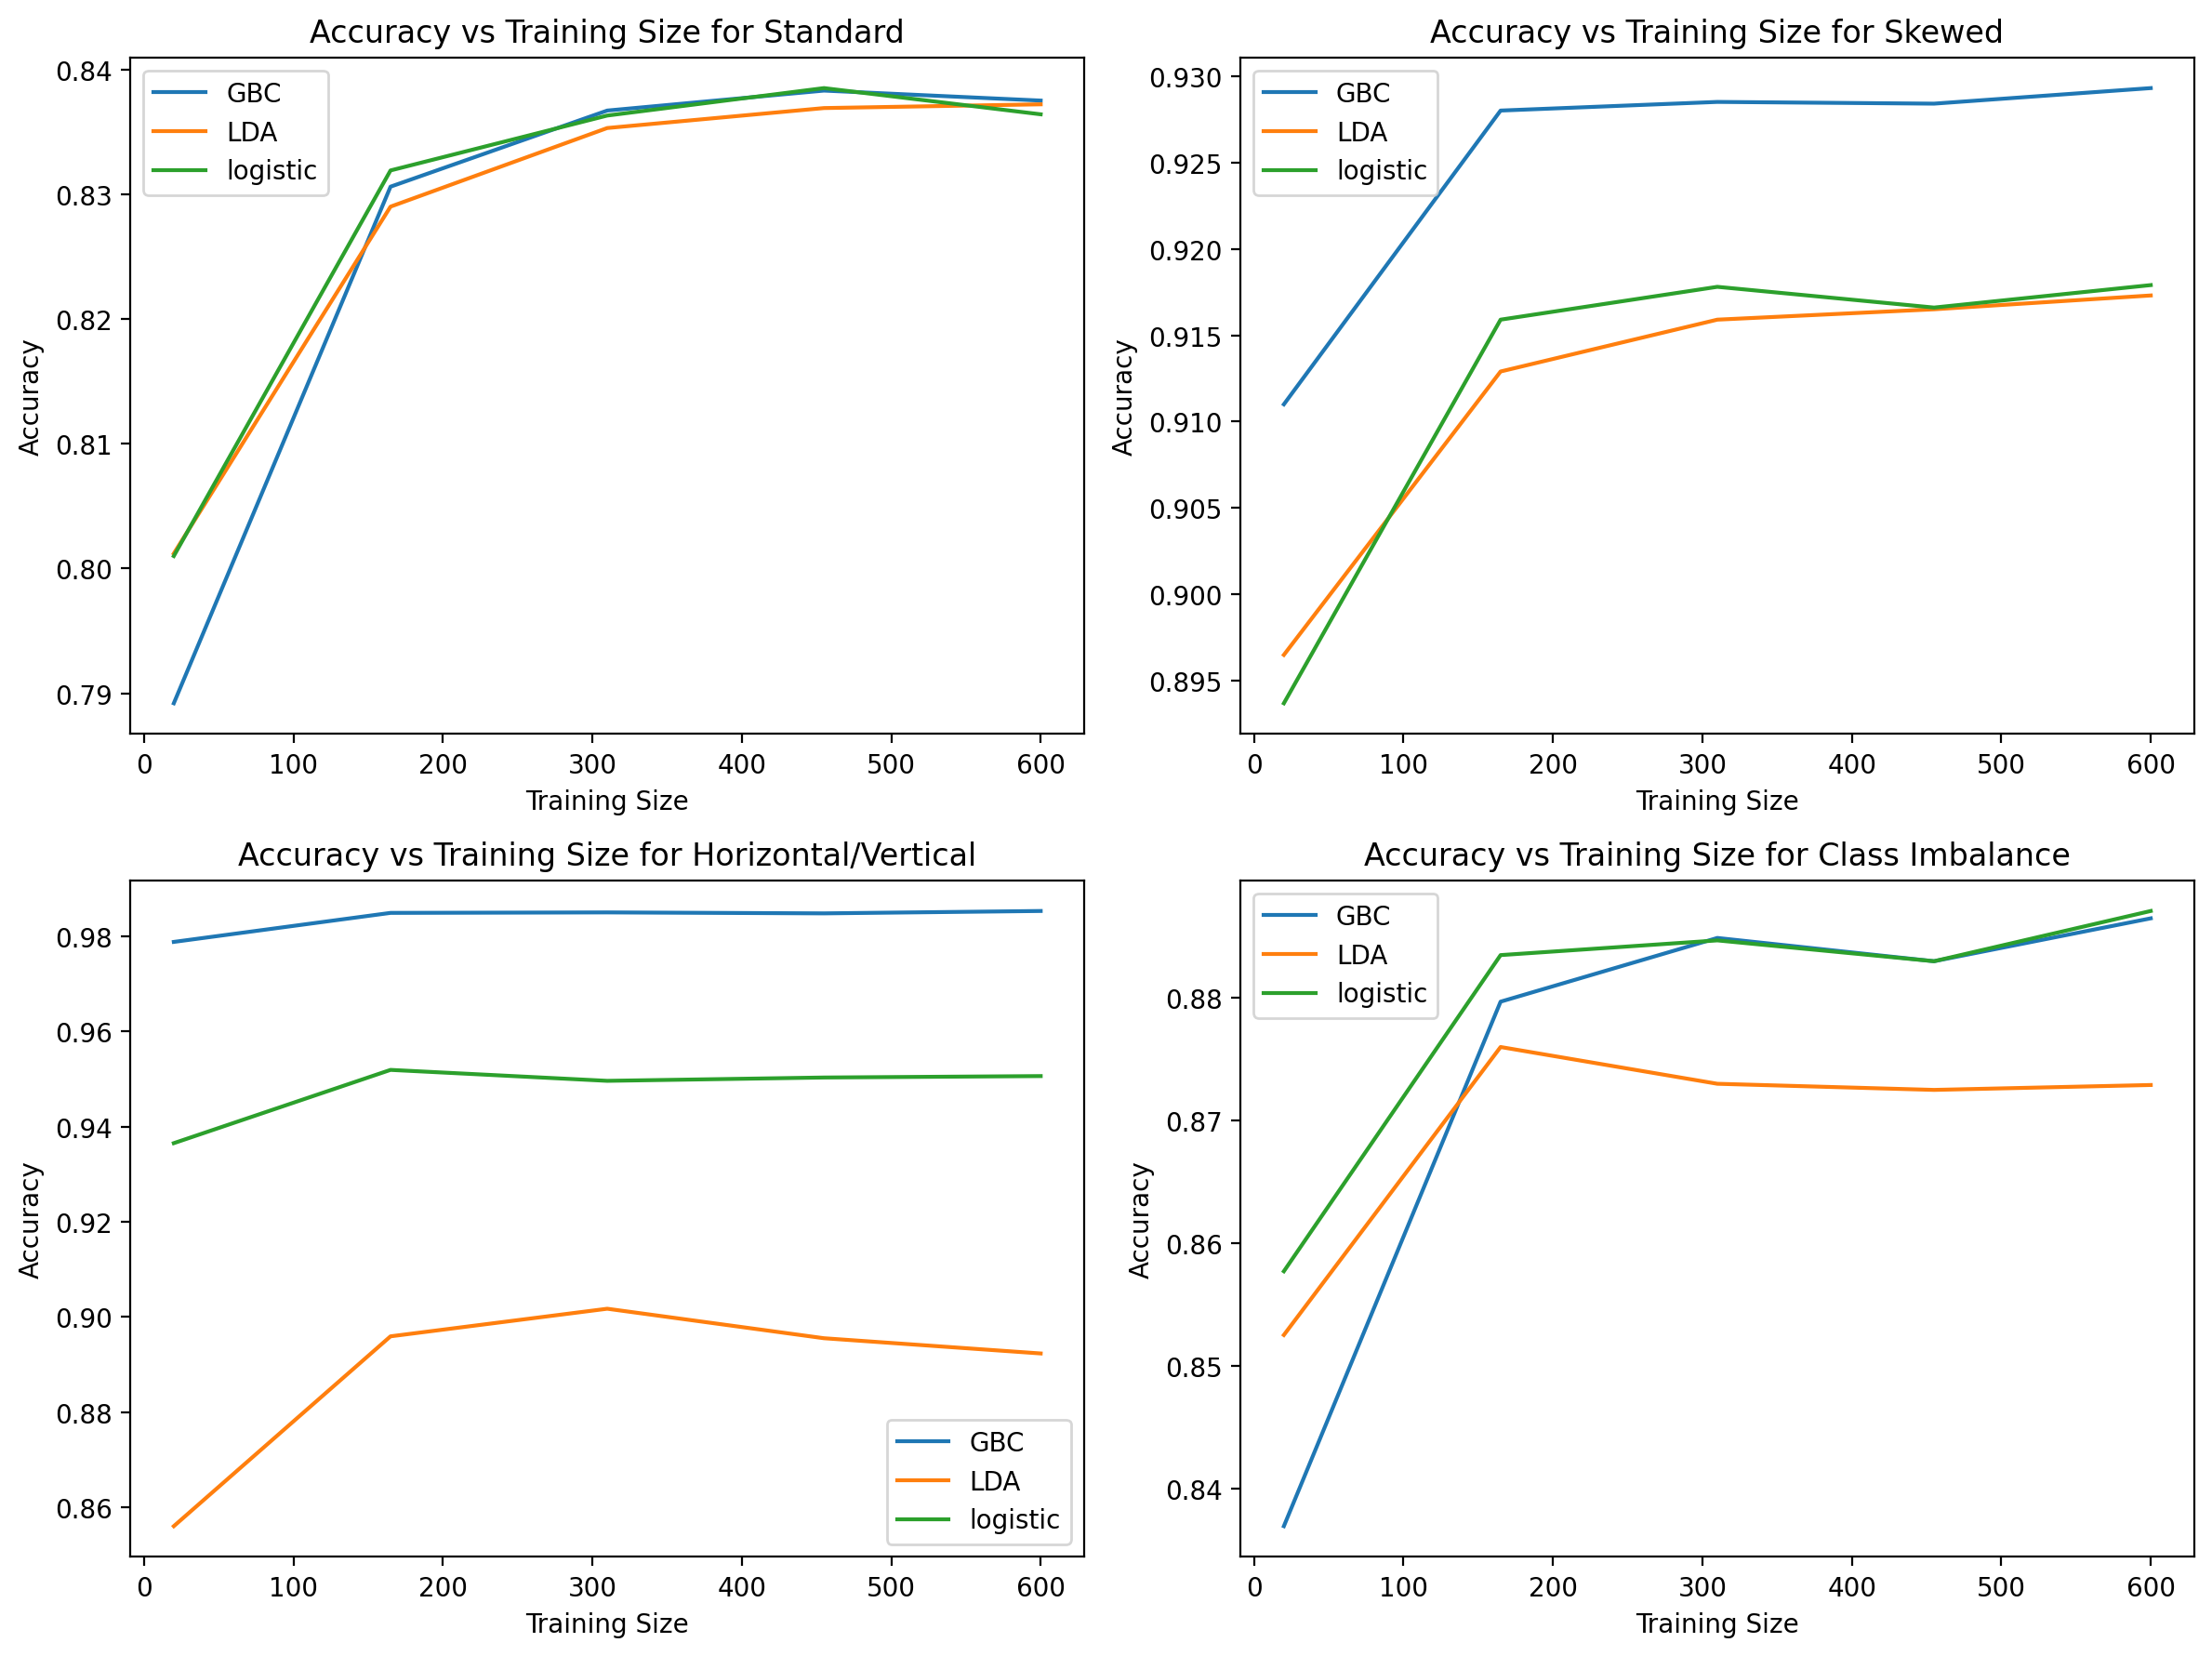

In [110]:
import matplotlib.pyplot as plt

training_sizes = np.linspace(20, 600, 5).astype(int)
n_reps = 10
accuracies = {source_name: {method_name: np.zeros(len(training_sizes)) for method_name in methods.keys()} for source_name in sources.keys()}

# Loop over each dataset
for source_name, source_func in sources.items():
    for _ in range(n_reps):
        X_test, y_test = source_func(1000)
        for ts_idx, m in enumerate(training_sizes):
            X_train, y_train = source_func(m)
            while len(np.unique(y_train))<2:
                X_train, y_train = source_func(m)
            # Loop over each method
            for method_name, method in methods.items():
                n_pos = np.sum(y_train == 1)
                n_neg = np.sum(y_train == -1)
                if n_pos < 2 or n_neg < 2:
                    print("too few samples:", m, "pos", n_pos, "neg", n_neg)
                method.fit(X_train, y_train)
                accuracy = method.score(X_test, y_test)
                accuracies[source_name][method_name][ts_idx] += accuracy / n_reps

# Plot the accuracies
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for idx, (source_name, source_accuracies) in enumerate(accuracies.items()):
    ax = axes[int(idx/2)][idx%2]
    for method_name, method_accuracies in source_accuracies.items():
        ax.plot(training_sizes, method_accuracies, label=method_name)
    ax.set_title(f'Accuracy vs Training Size for {source_name}')
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.tight_layout()
plt.show()